# Between Child and Machine: Where Does Adult Second Language Acquisition Sit on the Learning Spectrum? A Mandarin Case Study 
##### *Author: Slavena Peneva-Kargiou*  
##### *Course: SoftUni Machine Learning* 
##### *Instructor: Yordan Darakchiev*
##### *Date: June 2026*

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'jieba'], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, KFold)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, classification_report)
from sklearn.decomposition import PCA
from collections import Counter
import jieba
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# 1. Introduction

## 1.1 Motivation and Context
Children learning their first language acquire words in a consistent and well-documented order. Concrete nouns and social words come first - the things they can see, touch and point at. Pronouns, connectors and quantifiers are among the most common words in speech, yet children learn them last precisely because they refer to nothing in the physical world.

Language models learn differently. Their signal is statistical: a word that appears frequently in many different contexts becomes well represented. There is no embodied grounding and no emotional attachment to the sound of a word before its meaning arrives.

As a parent in a multilingual household wathching how my young children acquire language, I became interested in the apparent gap between how humans and language models learn words. In an earlier project, I examined this gap using English child vocabulary data from the Wordbank database and the BabyLM corpus - a curated collection of child-directed English text used to train language models.

The present project extends that line of inquiry and was also inspired by personal experience. I learned Mandarin as an adult, deliberately, through structured study and largely through text. There was no pointing at things and no emotional connection to the language and its speakers. That experience feels structurally different from how children learn their first language and, in some ways, more similar to what a language model does. Both an adult second-language (L2) learner and a language model rely heavily on text and explicit pattern recognition. Neither acquires the language through the embodied emotionally-driven process that characterizes child first-language (L1) acquisition.

This project follows that intuition with data and ML models using Mandarin as the common language across all three learners and tries to answer the following question: Do the statistical features that predict word acquisition order differ between children learning Mandarin as L1 and adults learning it as L2, and does the adult L2 pattern more closely resemble a language model's frequency-driven learning signal?

## 1.2 The Three Learners
All three learners in this project are working on the same language - Mandarin. Apart from my personal experience learning it as an adult, it is also used for practical and conceptual reasons. Practically, all required datasets are available in Mandarin. Conceptually, it is typologically distant from the Indo-European languages, making it an interesting case.
### 1.2.1 Children
I am using Wordbank Mandarin (Beijing) CDI data. Acquisition order is measured as age of acquisition (AoA) - the youngest age in months at which at least 50% of children produce a given word.
### 1.2.2 Adult L2 learners
HSK level is the vocabulary grading from China's official Mandarin proficiency framework, the Hanyu Shuiping Kaoshi. I use the old HSK system (6 levels, approximately 5000 words), whereby HSK level 1 contains the 150 most basic words, while HSK level 6 is the most advanced. Important limitation stated upfront: the HSK level reflects curriculum design decisions based on expert judgement about what adult learners need to know, not on empirical measurement of what they actually learn first.
### 1.2.3 Language model
It is represented by word frequency in the Chinese BabyLM corpus, a 100-million-token Mandarin corpus designed for the Chinese BabyLM Challenge and built on the same developmental plausibility features as the English BabyLM corpus. Frequency is the model's primary learning signal.

## 1.3 Positioning Statement
The BabyLM challenge (Warstadt et al., 2023 onwards) and its Chinese counterpart (Chinese BabyLM Challenge, Hu et al.) train language models on developmentally plausible data, using child acquisition as the benchmark for human-like language learning. This project does not enter either challenge but engages with their central premise, and furthermore asks whether adult L2 acquisition might be a natural complement or alternative reference point to child acquisition when thinking about how models learn language.

No such three-way comparison - children, adult L2 learners and language models, on the same language, appears to exist in the published literature. This is an exploratory study. The datasets are real, the methods are careful and the conclusions are stated honestly. Every limitation is acknowledged explicitly.

## 1.4 Theoretical Framework and Hypotheses
The three learners in this project occupy different positions on a spectrum defined by how much they rely on embodied social experience versus statistical patterns in text when acquiring language.

Children learning L1 are at the fully embodied end. Their early vocabulary is shaped by what they can perceve and interact with, which is why concreteness drives acquisition order.

Adult L2 learners occupy a middle position. They bring full conceptual knowledge of the world to the new language, but their learning is primarily text driven and explicit.

Language models are at the fully statistical end, with frequency serving as one of the strongest available indicators of the statistical learning signal they receive.

This suggests three testable predictions:

$
H_1: \text{Frequency is a stronger predictor of adult L2 acquisition order (HSK level) than of child L1 acquisition order (AoA).}
$

$
H_2: \text{Concreteness is a weaker predictor of adult L2 acquisition order than of child L1 acquisition order.}
$

$
H_3: \text{The overall feature importance profile of the adult L2 model resembles the model's frequency-based learning signal more closely than the child model does.}
$

These are exploratory predictions, not formal null hypotheses. The project follows them with data and reports what it finds.

# 2. The Datasets
Four datasets provide the raw material for this project. Two provide the target variables - AoA for children (Wordbank) and HSK level for adult L2 learners. One provides the model's learning signal - word frequency from the Chinese BabyLM corpus. One provides concreteness ratings - initially Xu & Li (2020), later suplemented by Liu et al. (2007) for reasons explained below. Word length in characters is derived directly from the word strings and requires no external source.

The datasets are merged into two parallel analysis datasets:
- Child dataset: Wordbank words with AoA and all available features
- Adult dataset: HSK words with HSK level and all available features


## 2.1 Wordbank Mandarin
Wordbank (wordbank.stanford.edu) is the largest open repository of children's vocabulary development data, aggregating responses from the MacArthur-Bates Communicative Development Inventory (CDI) across 42 languages. The Beijing Mandarin WS form is used here, covering children aged 16-30 months. Each word in the dataset has a production proportion for each age in month - the fraction of children reported to produce that word at that age. AoA is defined as the youngest age at which this proportion first reaches or exceeds 50%.

The Wordbank data uses Chinese characters throughout. Some entries contain parenthetical notes or punctuation that do not appear in any other dataset, for example 旺旺（狗叫）meaning "woof woof (dog sound)". These are stripped before merging. 

In [2]:
df_wordbank = pd.read_csv('wordbank_mandarin_items.csv',
                           encoding='utf-8', quoting=3)
df_wordbank.columns = [c.strip('"') for c in df_wordbank.columns]
df_wordbank['item_definition'] = df_wordbank['item_definition'].str.strip('"')
df_wordbank['category'] = df_wordbank['category'].str.strip('"')

# Strip parenthetical disambiguators e.g. 旺旺（狗叫）→ 旺旺
# These appear in Wordbank but not in any other dataset
df_wordbank['word'] = df_wordbank['item_definition']\
    .str.replace(r'（[^）]*）', '', regex=True)\
    .str.replace(r'\([^)]*\)', '', regex=True)\
    .str.replace(r'[？！。，、]', '', regex=True)\
    .str.strip()

# Further cleaning — strip spaces, take first slash-separated option,
# remove trailing punctuation
df_wordbank['word'] = df_wordbank['word']\
    .str.replace(' ', '', regex=False)\
    .apply(lambda w: w.split('/')[0] if '/' in w else w)\
    .str.replace(r'[！!？?。，、]', '', regex=True)\
    .str.strip()

age_cols = [str(a) for a in range(16, 31)]

def compute_aoa(row, threshold=0.5):
    """Return the first age (months) at which >= 50% of children produce the word."""
    for age in age_cols:
        try:
            if float(row[age]) >= threshold:
                return int(age)
        except:
            pass
    return np.nan

df_wordbank['aoa'] = df_wordbank.apply(compute_aoa, axis=1)
df_aoa = df_wordbank[['word', 'category', 'aoa']].copy()

print(f"Total Wordbank words:             {len(df_aoa)}")
print(f"Words with AoA defined (≥50%):   {df_aoa['aoa'].notna().sum()}")
print(f"Words never reaching threshold:  {df_aoa['aoa'].isna().sum()}")
display(df_aoa.head(5))

Total Wordbank words:             799
Words with AoA defined (≥50%):   772
Words never reaching threshold:  27


,word,category,aoa
0,喂,sounds,16.0
1,旺旺,sounds,16.0
2,喵,sounds,16.0
3,嘀嘀,sounds,17.0
4,哎哟,sounds,17.0


## 2.2 HSK Vocabulary Lists
The old HSK system (6 levels, approximately 5000 words) is used, rather than the recent version introduced in 2026, as its vocabulary lists are well-established and readily available for analysis. The words appearing in multiple levels are resolved by keeping the lowest level - since level 1 means learned first, this seems to be the most logical and methodologically appropriate choice.

In [3]:
hsk_dfs = []
for level in range(1, 7):
    df = pd.read_csv(f'hsk{level}.csv',
                     header=None, names=['word', 'pinyin', 'english'])
    df['hsk_level'] = level
    hsk_dfs.append(df)

df_hsk = pd.concat(hsk_dfs, ignore_index=True)

# Resolve duplicates — keep lowest level
df_hsk = df_hsk.sort_values('hsk_level').drop_duplicates(
    subset='word', keep='first').reset_index(drop=True)

print(f"Total HSK words after deduplication: {len(df_hsk)}")
print(f"\nWords per level:")
print(df_hsk['hsk_level'].value_counts().sort_index())
display(df_hsk.head(5))

Total HSK words after deduplication: 4993

Words per level:
hsk_level
1     150
2     147
3     298
4     598
5    1300
6    2500
Name: count, dtype: int64


,word,pinyin,english,hsk_level
0,开,kāi,to open,1
1,看,kàn,to see,1
2,看见,kàn jiàn,to see,1
3,块,kuài,lump (of earth),1
4,来,lái,to come,1


## 2.3 Chinese BabyLM Corpus - Computing Word Frequencies
The Chinese BabyLM corpus is a 100-million-token Mandarin dataset built from child-directed speech, children's books, educational text and subtitles, designed for the Chinese BabyLM Challenge. It is the Mandarin equivalent of the English BabyLM corpus and provides the model's learning signal throughout this project.

Word frequencies are computed using jieba, the standard Chinese word segmentation library, which splits unsegmented Chinese text into words. Because this computation takes some time on the full corpus, the results are saved to a csv file. This precomputed file is included in the project Google Drive folder so the notebook can be run without repeating the computation.


In [4]:
# Pre-computed frequency file: babylm_zh_frequencies.csv
# Included in the project's Google Drive folder, link available in Section 8. References
# Please download and place in the same directory as this notebook to skip the computation step.

FREQ_CACHE = 'babylm_zh_frequencies.csv'

if os.path.exists(FREQ_CACHE):
    # Load pre-computed frequencies — no need to reprocess
    df_freq = pd.read_csv(FREQ_CACHE)
    print(f"Loaded pre-computed frequencies: {len(df_freq):,} unique words")
else:
    # Compute from scratch — only needed once
    print("Computing frequencies from Chinese BabyLM corpus...")
    df_babylm = pd.read_parquet('train-00000-of-00001.parquet')
    print(f"Corpus: {len(df_babylm):,} documents")
    print(f"Categories: {df_babylm['category'].value_counts().to_dict()}")

    word_counts = Counter()
    for i, text in enumerate(df_babylm['text']):
        words = jieba.lcut(str(text))
        word_counts.update(words)
        if (i + 1) % 10000 == 0:
            print(f"  Processed {i+1:,} / {len(df_babylm):,} documents...")

    df_freq = pd.DataFrame({
        'word':      list(word_counts.keys()),
        'frequency': list(word_counts.values())
    })

    # Remove punctuation, whitespace and non-Chinese tokens
    # \u4e00-\u9fff is the Unicode range covering all standard Chinese characters
    chinese_pattern = re.compile(r'[\u4e00-\u9fff]')
    df_freq = df_freq[df_freq['word'].apply(
        lambda w: bool(chinese_pattern.search(str(w)))
    )].copy().reset_index(drop=True)
    print(f"After cleaning: {len(df_freq):,} unique Chinese words")

    # Save for future use
    df_freq.to_csv(FREQ_CACHE, index=False, encoding='utf-8-sig')
    print(f"Saved to {FREQ_CACHE}")

print(f"\nFrequency range: {df_freq['frequency'].min():,} – "
      f"{df_freq['frequency'].max():,}")
print(f"Total tokens: {df_freq['frequency'].sum():,}")
display(df_freq.sort_values('frequency', ascending=False).head(10))

Loaded pre-computed frequencies: 606,029 unique words

Frequency range: 1 – 3,898,022
Total tokens: 75,761,588


,word,frequency
5,的,3898022
238,我,2415696
25,了,2255739
241,你,2078294
158,是,1403442
248,啊,842693
39,在,767953
105,就,745045
22,他,727203
120,不,574433


The token count after cleaning (less than 76 million) is lower than the corpus' nominal 100 million tokens because punctuation, whitespace and non-Chinese tokens are excluded - only Chinese character sequences are retained.

## 2.4 Xu & Li Concreteness Norms
Xu & Li (2020) provide concreteness ratings for 9877 two-character Chinese words collected from native Mandarin speakers. 

One important preprocessing step: the Xu & Li scale runs from 1 (very concrete) to 5 (very abstract) - the inverse of standard direction used in most English-language research. To ensure consistency with my earlier project, scores are reversed before the analysis:
$$\text{concreteness} = 6 - \text{concreteness}_{\text{original}}$$
After reversal, a score of 5 indicates maximum concreteness and a score of 1 indicates maximum abstractness (This was later changed to a 0-1 scale for reasons discussed below).

In [5]:
df_xuli = pd.read_excel(
    'Concretenss_Ratings_of_9877_Two_Character_Chinese_Words.xlsx')
df_xuli = df_xuli.rename(columns={
    'Word':                  'word',
    'Mean of Valid Ratings': 'concreteness_raw'
})
df_xuli['word'] = df_xuli['word'].str.strip()

# Reverse scale: original 1=concrete, 5=abstract → reversed 5=concrete, 1=abstract
df_xuli['concreteness'] = 6 - df_xuli['concreteness_raw']

print(f"Xu & Li norms: {len(df_xuli):,} words")
print(f"Reversed scale range: {df_xuli['concreteness'].min():.2f} – "
      f"{df_xuli['concreteness'].max():.2f}  (1=abstract, 5=concrete)")
display(df_xuli[['word', 'concreteness_raw', 'concreteness']].head(5))

Xu & Li norms: 9,877 words
Reversed scale range: 1.44 – 4.96  (1=abstract, 5=concrete)


,word,concreteness_raw,concreteness
0,暗笑,2.666667,3.333333
1,黯然,4.185185,1.814815
2,昂首,2.222222,3.777778
3,白人,1.629630,4.370370
4,绑架,1.777778,4.222222


To assess coverage I performed a preliminary merge before commiting to this dataset as the sole concreteness source:

In [6]:
df_freq['log_frequency'] = np.log10(df_freq['frequency'].clip(lower=1))

def preliminary_merge(df_target, target_col):
    """Quick merge to check feature coverage."""
    df = df_target[['word', target_col]].copy()
    df = df.merge(df_freq[['word', 'log_frequency']], on='word', how='left')
    df = df.merge(df_xuli[['word', 'concreteness']], on='word', how='left')
    df['word_length'] = df['word'].str.len()
    return df

df_child_prelim = preliminary_merge(
    df_aoa.dropna(subset=['aoa']), 'aoa')
df_adult_prelim = preliminary_merge(df_hsk, 'hsk_level')

print("Coverage with Xu & Li alone:")
print(f"  Child:  {df_child_prelim[['aoa','log_frequency','concreteness']].notna().all(axis=1).sum()} / {len(df_child_prelim)} words")
print(f"  Adult:  {df_adult_prelim[['hsk_level','log_frequency','concreteness']].notna().all(axis=1).sum()} / {len(df_adult_prelim)} words")

Coverage with Xu & Li alone:
  Child:  194 / 772 words
  Adult:  2757 / 4993 words


The results here are rather disappointing. Only 194 child words with all features present out of 772 is obviously too small a basis for ML models. The problem is concreteness - the Xu & Li dataset exclusively covers two-character words. However, early child vocabulary is dominated by single-character words like 我 (I), 你 (you), 水 (water), 狗 (dog), as well as reduplicated words where the same character is doubled, like 妈妈 (mom), 爸爸 (dad), 姐姐 (older sister), 宝宝 (baby). These are among the most concrete and earliest acquired words in Mandarin, yet they are entirely absent from the Xu & Li norms. This is something that definitely needed to be addressed, yet, as it appeared, no single freely available concreteness dataset covers all these types of words. The logical solution was to find a complementary dataset.

## 2.5 Liu et al. (2007) Concreteness Norms - Single Characters
Liu et al. (2007) provide psycholinguistic norms including concreteness for 2390 simplified Mandarin single-character words, collected from 480 native Chinese speakers. The database is freely accessible online at the Chinese Single-character Word Database (CSWD). The concreteness scale runs from 0 to 7 where higher scores indicate greater concreteness. This coincides with the direction I am using throughout the project, so no reversal is needed.

To combine Liu et al. with Xu & Li, both datasets are normalized to a common 0-1 scale using min-max normalization:

$$
\text{concreteness}_{\text{norm}} =
\frac{\text{score} - \text{min}}{\text{max} - \text{min}}
$$

The two datasets cover non-overlapping vocabulary - single-character and two-character resepctively. Therefore, there is no need for deduplication and they are simply concatenated after normalization. 


In [7]:
df_liu = pd.read_csv('liu_2007_single_char.txt', sep='\t',
                      encoding='utf-8')
df_liu = df_liu.rename(columns={
    'Word': 'word',
    'CON':  'concreteness_raw'  # adjust to actual column name
})
df_liu['word'] = df_liu['word'].str.strip()

print(f"Liu et al. norms: {len(df_liu):,} single-character words")
print(f"Scale range: {df_liu['concreteness_raw'].min():.2f} – "
      f"{df_liu['concreteness_raw'].max():.2f}  (higher = more concrete)")

# Verify direction — most concrete words should be tangible objects
print("\nMost concrete words (highest scores):")
display(df_liu.nlargest(5, 'concreteness_raw')[['word', 'concreteness_raw']])
print("\nMost abstract words (lowest scores):")
display(df_liu.nsmallest(5, 'concreteness_raw')[['word', 'concreteness_raw']])

Liu et al. norms: 2,356 single-character words
Scale range: 1.90 – 7.00  (higher = more concrete)

Most concrete words (highest scores):


,word,concreteness_raw
1012,梨,7.00
1132,猫,7.00
1583,鼠,7.00
1673,桃,7.00
1526,绳,6.97



Most abstract words (lowest scores):


,word,concreteness_raw
737,即,1.90
1856,现,2.20
462,菲,2.23
2220,臻,2.25
515,该,2.35


In [8]:
def normalize_concreteness(series):
    """Min-max normalize concreteness scores to 0-1 range."""
    return (series - series.min()) / (series.max() - series.min())

df_xuli['concreteness_norm'] = normalize_concreteness(df_xuli['concreteness'])
df_liu['concreteness_norm'] = normalize_concreteness(df_liu['concreteness_raw'])

# Concatenate directly — no overlap between single-character and two-character datasets
df_concrete_combined = pd.concat([
    df_xuli[['word', 'concreteness_norm']],
    df_liu[['word', 'concreteness_norm']]
], ignore_index=True)

print(f"Xu & Li coverage:        {len(df_xuli):,} words")
print(f"Liu et al. coverage:     {len(df_liu):,} words")
print(f"Combined total:          {len(df_concrete_combined):,} words")

Xu & Li coverage:        9,877 words
Liu et al. coverage:     2,356 words
Combined total:          12,233 words


## 2.6 Handling Reduplicated Words
Mandarin contains a class of words formed by doubling a single character, for example 爸爸 (dad), 弟弟 (younger brother), etc. These appear frequently in Wordbank but are absent from both concreteness datasets because they are two-character words derived from single characters.

Their concreteness is derived from the base character's rating in the Liu et al. dataset, because linguistically reduplicated words derive their meaning entirely from the base character.

In [9]:
def is_reduplication(word):
    """Return True if word is a two-character reduplication (e.g. 妈妈)."""
    return len(word) == 2 and word[0] == word[1]

# Build lookup from Liu et al. normalized scores
liu_lookup = dict(zip(df_liu['word'], df_liu['concreteness_norm']))

# Find reduplicated Wordbank words still missing concreteness after main merge
missing_conc_words = df_aoa[
    ~df_aoa['word'].isin(df_concrete_combined['word'])
]['word'].tolist()

reduplications = [w for w in missing_conc_words if is_reduplication(w)]
print(f"Reduplicated words missing concreteness: {len(reduplications)}")
print(reduplications)

# Create supplementary concreteness entries for reduplications
reduplication_rows = []
for word in reduplications:
    base_char = word[0]
    if base_char in liu_lookup:
        reduplication_rows.append({
            'word': word,
            'concreteness_norm': liu_lookup[base_char]
        })

df_reduplications = pd.DataFrame(reduplication_rows)
print(f"\nReduplications with base character in Liu et al.: "
      f"{len(df_reduplications)}")

# Add to combined concreteness dataset
df_concrete_final = pd.concat([
    df_concrete_combined,
    df_reduplications
], ignore_index=True).drop_duplicates(subset='word', keep='first')

print(f"\nFinal concreteness dataset: {len(df_concrete_final):,} unique words")

Reduplicated words missing concreteness: 26
['旺旺', '嘀嘀', '咩咩', '嘎嘎', '梆梆', '喳喳', '爸爸', '奶奶', '姥姥', '爷爷', '宝宝', '姑姑', '叔叔', '伯伯', '舅舅', '姐姐', '妹妹', '哥哥', '弟弟', '等等', '画画', '数数', '掸掸', '猩猩', '蛐蛐', '星星']

Reduplications with base character in Liu et al.: 17

Final concreteness dataset: 12,250 unique words


## 2.7 Building the Two Parallel Datasets
With the combined concreteness source in place, the two analysis datasets are built using the same merge structure.

In [10]:
def build_dataset(df_target, target_col, word_col='word'):
    """
    Merge a target dataset (Wordbank or HSK) with all feature sources.
    Left join on target words — all target words retained,
    features added where available.
    """
    df = df_target[[word_col, target_col]].copy()
    if 'category' in df_target.columns:
        df['category'] = df_target['category']

    # Frequency from Chinese BabyLM corpus
    df = df.merge(df_freq[['word', 'frequency', 'log_frequency']],
                  on='word', how='left')

    # Concreteness — combined from Xu & Li, Liu et al., and reduplications
    df = df.merge(df_concrete_final[['word', 'concreteness_norm']],
                  on='word', how='left')
    df = df.rename(columns={'concreteness_norm': 'concreteness'})

    # Word length in characters — derived directly
    df['word_length'] = df['word'].str.len()

    return df

df_child = build_dataset(df_aoa.dropna(subset=['aoa']), target_col='aoa')
df_adult = build_dataset(df_hsk, target_col='hsk_level')

FEATURES = ['log_frequency', 'concreteness', 'word_length']

for name, df, target in [('Child (Wordbank)', df_child, 'aoa'),
                           ('Adult (HSK)',     df_adult, 'hsk_level')]:
    print(f"=== {name} ===")
    print(f"Total words:        {len(df)}")
    print(f"With frequency:     {df['frequency'].notna().sum()}")
    print(f"With concreteness:  {df['concreteness'].notna().sum()}")
    print(f"With all features:  "
          f"{df[[target]+FEATURES].notna().all(axis=1).sum()}")
    print()

# Final analysis datasets — words with all features present
df_child_analysis = df_child.dropna(
    subset=['aoa'] + FEATURES).copy().reset_index(drop=True)
df_adult_analysis = df_adult.dropna(
    subset=['hsk_level'] + FEATURES).copy().reset_index(drop=True)

print(f"Final child analysis dataset:  {len(df_child_analysis)} words")
print(f"Final adult analysis dataset:  {len(df_adult_analysis)} words")

=== Child (Wordbank) ===
Total words:        772
With frequency:     743
With concreteness:  505
With all features:  504

=== Adult (HSK) ===
Total words:        4993
With frequency:     4983
With concreteness:  3269
With all features:  3269

Final child analysis dataset:  504 words
Final adult analysis dataset:  3269 words


The two analysis datasets differ substantially in size - 504 child words versus 3269 adult words. This reflects both the smaller scope of the Wordbank checklist relative to the HSK vocabulary lists, as well as the differential coverage of available concreteness norms across word types.

## 2.8 What Gets Lost in the Merge and Why

In [11]:
missing_child_freq = df_child[
    df_child['frequency'].isna()]['word'].tolist()
missing_child_conc = df_child[
    df_child['concreteness'].isna() &
    df_child['frequency'].notna()]['word'].tolist()
missing_adult_freq = df_adult[
    df_adult['frequency'].isna()]['word'].tolist()
missing_adult_conc = df_adult[
    df_adult['concreteness'].isna() &
    df_adult['frequency'].notna()]['word'].tolist()

print(f"Child words missing from corpus ({len(missing_child_freq)}):")
print(missing_child_freq[:15])
print(f"\nChild words missing concreteness ({len(missing_child_conc)}):")
print(missing_child_conc[:15])
print(f"\nHSK words missing from corpus ({len(missing_adult_freq)}):")
print(missing_adult_freq[:15])
print(f"\nHSK words missing concreteness ({len(missing_adult_conc)}):")
print(missing_adult_conc[:15])

Child words missing from corpus (29):
['咩咩', '嘎嘎达', '自己的名字', '小朋友的名字', '藏猫猫', '抓住了', '你拍一我拍一', '好吧', '对了', '亮了', '倒了', '掸掸', '没了', '坏了', '破了']

Child words missing concreteness (239):
['喂', '喵', '嘀嘀', '哎哟', '呀', '梆梆', '喳喳', '嗷', '姥姥', '姥爷', '阿姨', '大妈', '唐老鸭', '米老鼠', '孙悟空']

HSK words missing from corpus (10):
['呢,ne,particle indicating that a previously asked question is to be applied to the preceding word ("What about ...?"', '不客气', '比,bǐ,(particle used for comparison and "-er than")', '分之', '系领带', '要不', '和气', '纽扣儿', '哇,wa,replaces 啊 when following the vowel "u" or "ao";', '无可奉告,wú kě fèng gào,(idiom) "no comment";']

HSK words missing concreteness (1714):
['块', '了', '你', '年', '女儿', '谁', '什么', '十', '时候', '四', '岁', '他', '她', '太', '喂']


The remaining merge losses fall into identifiable and linguistically interpretable categories.

Child words missing from the corpus are represented by certain game chants, phrases and slash-separated alternatives, that exist as single Wordbank items but cannot be matched to corpus tokens. Child words still missing concreteness include sound words whose base characters have no independent meaning, as well as proper names of fictional characters like 唐老鸭 (Donald Duck) and 米老鼠 (Mickey Mouse). The 1714 HSK words missng concreteness include very common words like 你 (you), 他 (he), 了 (aspect marker). This is not a data quality problem - both Liu et al., and Xu & Li deliberately exclude pronouns, particles and functional words, because concreteness as a psycholinguistic construct has no meaningful application to purely grammatical words. The missing words are therefore not random: they are systematically the most grammatical end of the HSK vocabulary, and the adult analysis dataset is biased toward content words as a result. There are also 10 HSK entries that could not be matched to the corpus and were excluded from further analysis due to their heterogenous nature and negligible impact on the overall dataset.

The size difference between the two final datasets - 504 child words versus 3269 adult words, reflects these combined gaps. Absolute model performance metrics such as $R^2$ and classification accuracy are not directly comparable between the two models. The analysis focuses on feature importance profiles and Spearman correlations, which are internally valid within each dataset and support meaningful comparison across them.

# 3. Exploratory Data Analysis

## 3.1 AoA and HSK Level Distributions

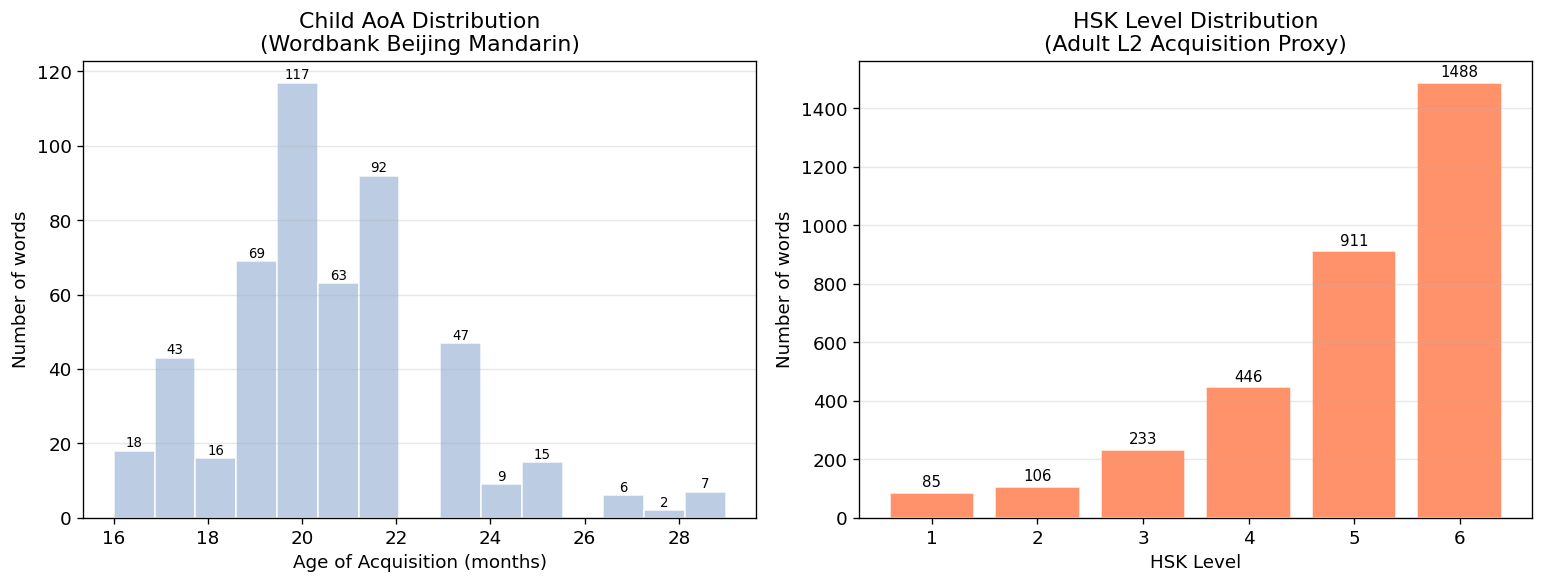

Child AoA summary statistics:
count    504.00
mean      20.63
std        2.43
min       16.00
25%       19.00
50%       20.00
75%       22.00
max       29.00
Name: aoa, dtype: float64

HSK level distribution:
hsk_level
1      85
2     106
3     233
4     446
5     911
6    1488
Name: count, dtype: int64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_child_analysis['aoa'], bins=15,
             color='lightsteelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Age of Acquisition (months)')
axes[0].set_ylabel('Number of words')
axes[0].set_title('Child AoA Distribution\n(Wordbank Beijing Mandarin)')
axes[0].grid(axis='y', alpha=0.3)

# Add counts on top of AoA histogram bars
for patch in axes[0].patches:
    height = patch.get_height()
    if height > 0:
        axes[0].text(patch.get_x() + patch.get_width() / 2,
                     height + 1, str(int(height)),
                     ha='center', fontsize=8)

level_counts = df_adult_analysis['hsk_level'].value_counts().sort_index()
axes[1].bar(level_counts.index, level_counts.values,
            color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('HSK Level')
axes[1].set_ylabel('Number of words')
axes[1].set_title('HSK Level Distribution\n(Adult L2 Acquisition Proxy)')
axes[1].set_xticks(range(1, 7))
axes[1].grid(axis='y', alpha=0.3)

# Add counts on top of HSK bars
for i, (level, count) in enumerate(level_counts.items()):
    axes[1].text(i + 1, count + 20, str(count),
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Child AoA summary statistics:")
print(df_child_analysis['aoa'].describe().round(2))
print("\nHSK level distribution:")
print(df_adult_analysis['hsk_level'].value_counts().sort_index())

The AoA distribution confirms that the child dataset captures the core vocabulary acquisition window - most words are acquired between 19 and 22 months, the period of early vocabulary burst in children. The HSK distribution reflects a deliberate curriculum design choice rather than natural acquisition order - basic vocabulary is small and advanced vocabulary is large, meaning that the adult proxy is structurally different from the child one even before any modelling begins.

## 3.2 Frequency Distributions and Zipf's Law

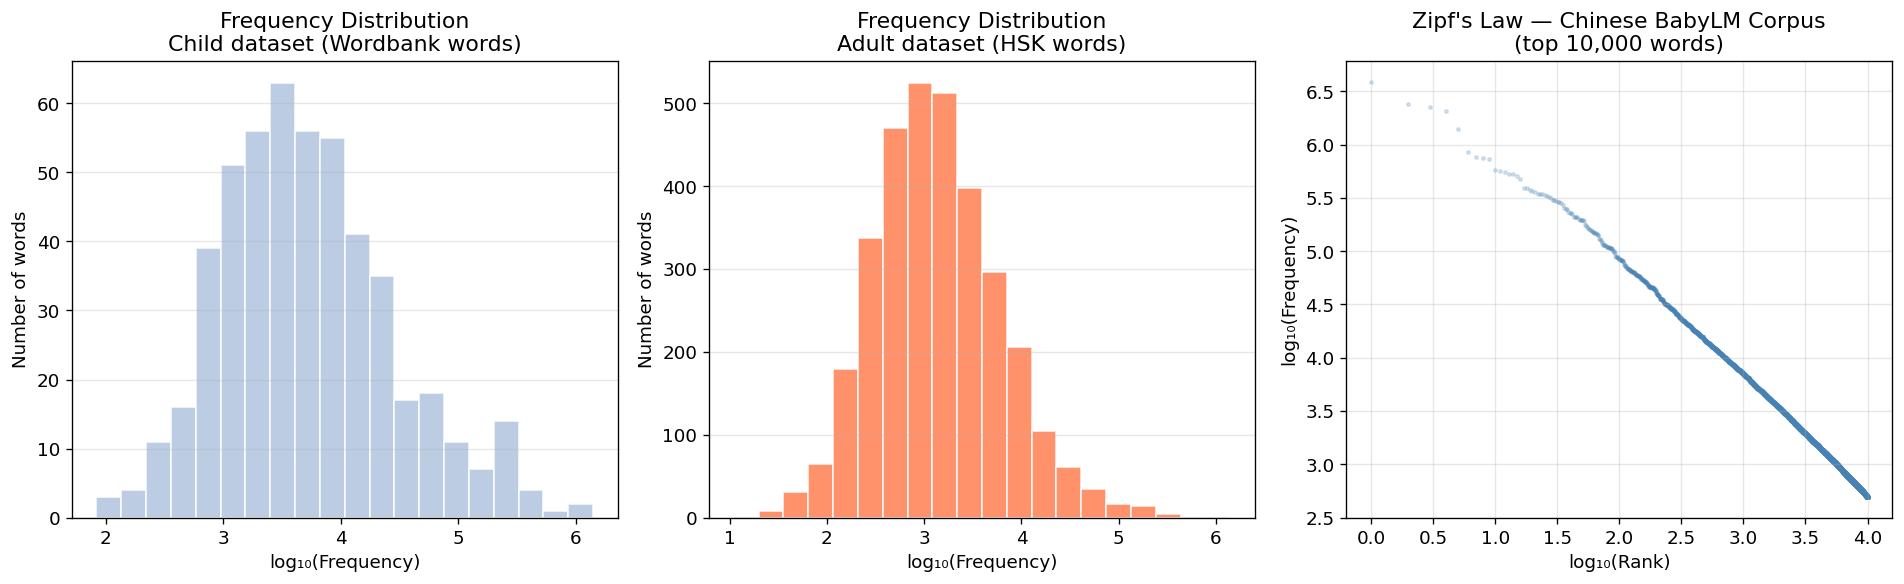

Frequency summary — child dataset:
count        504.0
mean       29292.0
std       106402.0
min           83.0
25%         1606.0
50%         4348.0
75%        14453.0
max      1403442.0
Name: frequency, dtype: float64

Frequency summary — adult dataset:
count       3269.0
mean        6031.0
std        32872.0
min           11.0
25%          497.0
50%         1229.0
75%         3482.0
max      1403442.0
Name: frequency, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Child frequency distribution
axes[0].hist(df_child_analysis['log_frequency'], bins=20,
             color='lightsteelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('log₁₀(Frequency)')
axes[0].set_ylabel('Number of words')
axes[0].set_title('Frequency Distribution\nChild dataset (Wordbank words)')
axes[0].grid(axis='y', alpha=0.3)

# Adult frequency distribution
axes[1].hist(df_adult_analysis['log_frequency'], bins=20,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log₁₀(Frequency)')
axes[1].set_ylabel('Number of words')
axes[1].set_title('Frequency Distribution\nAdult dataset (HSK words)')
axes[1].grid(axis='y', alpha=0.3)

# Zipf's law — full corpus
freq_sorted = df_freq.sort_values(
    'frequency', ascending=False).reset_index(drop=True)
freq_sorted['rank'] = freq_sorted.index + 1
axes[2].scatter(np.log10(freq_sorted['rank'][:10000]),
                np.log10(freq_sorted['frequency'][:10000]),
                alpha=0.2, s=4, color='steelblue')
axes[2].set_xlabel("log₁₀(Rank)")
axes[2].set_ylabel("log₁₀(Frequency)")
axes[2].set_title("Zipf's Law — Chinese BabyLM Corpus\n(top 10,000 words)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Frequency summary — child dataset:")
print(df_child_analysis['frequency'].describe().round(0))
print("\nFrequency summary — adult dataset:")
print(df_adult_analysis['frequency'].describe().round(0))

Both frequency distributions are plotted on a log scale - a standard choice when working with word frequencies which span several orders of magnitude and are strongly right-skewed in their raw form. The log transformation compresses this range and makes the distribution readable and easier to compare. Both distributions become substantially more symmetric after log transformation, indicating that both datasets contain words spanning a wide range of corpus frequencies. The child dataset shows a wider spread and a higher frequency (median 4348) than the adult dataset (median 1229) which is expected - Wordbank words are common everyday vocabulary while HSK covers a much wider range including rare advanced words.

The Zipf's law plot illustrates a fundamental property of natural language - word frequency follows a power law meaning that a small number of words account for the vast majority of occurrences while most words appear rarely. On a log-log scale this relationship appears as a straight line, which the Chinese BabyLM corpus follows closely. This asymmetry is directly relevant to this project, as it indicates that the model's learning signal is very strong for frequent words and very weak for rare ones, regardless of how concrete those rare words might be.

## 3.3 Concreteness Distributions

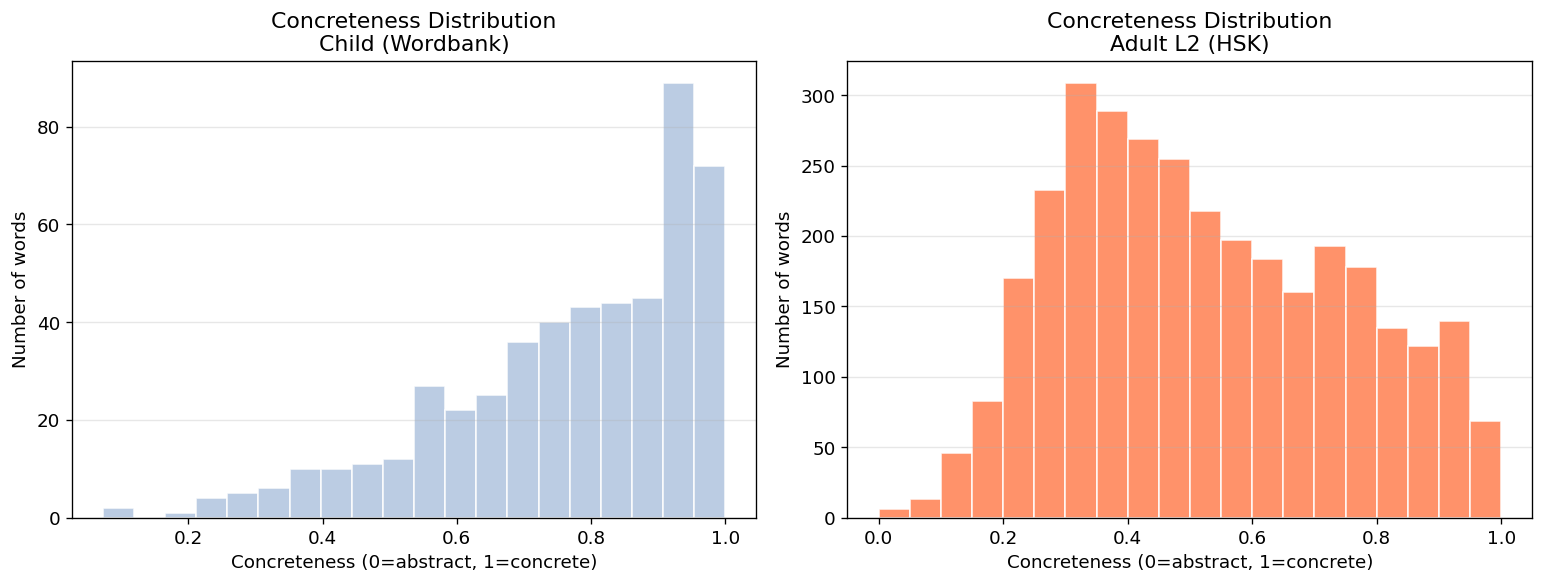

Concreteness — child dataset:
count    504.00
mean       0.77
std        0.19
min        0.07
25%        0.66
50%        0.81
75%        0.92
max        1.00
Name: concreteness, dtype: float64

Concreteness — adult dataset:
count    3269.00
mean        0.52
std         0.22
min         0.00
25%         0.34
50%         0.49
75%         0.71
max         1.00
Name: concreteness, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in [
    (axes[0], df_child_analysis, 'Child (Wordbank)', 'lightsteelblue'),
    (axes[1], df_adult_analysis, 'Adult L2 (HSK)',   'coral')
]:
    ax.hist(df['concreteness'], bins=20,
            color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Concreteness (0=abstract, 1=concrete)')
    ax.set_ylabel('Number of words')
    ax.set_title(f'Concreteness Distribution\n{label}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Concreteness — child dataset:")
print(df_child_analysis['concreteness'].describe().round(2))
print("\nConcreteness — adult dataset:")
print(df_adult_analysis['concreteness'].describe().round(2))

The two concreteness distributions look strikingly different. The child dataset is strongly left-skewed - the vast majority of Wordbank words score above 0.6 on the normalized scale, with a mean of 0.77 and a spike at the maximum. This is exactly what intuition would predict and aligns with the findings of my previous project - early child vocabulary is dominated by concrete, perceivable things. The adult HSK dataset is much more evenly spread, with a mean of 0.52, covering the full range from abstract to concrete. This reflects the broader scope of HSK - it includes not only concrete words, but also grammatical and abstract vocabulary that an adult learner needs accross all proficiency levels. Before any modeling, the two distributions already suggest that concreteness plays a structurally different role in the two vocabularies and, by extension, possibly in the two acquisition processes.

## 3.4 Spearman Correlations
Spearman rank correlations measure the strength and direction of the relationship between two variables based on their rankings rather than their raw values. It is used here instead of Pearson correlation because the target variables (AoA in months and HSK level) are better treated as ordinal rankings than as continuous measurements. 

In [15]:
features_display = {
    'Frequency (log)': 'log_frequency',
    'Concreteness':    'concreteness',
    'Word length':     'word_length'
}

print(f"{'Feature':<22} {'Child r':>10} {'Child p':>10} "
      f"{'Adult r':>10} {'Adult p':>10}")
print("-" * 65)

spearman_results = {}
for name, col in features_display.items():
    r_c, p_c = spearmanr(df_child_analysis['aoa'],
                          df_child_analysis[col])
    r_a, p_a = spearmanr(df_adult_analysis['hsk_level'],
                          df_adult_analysis[col])
    spearman_results[name] = {
        'child_r': r_c, 'child_p': p_c,
        'adult_r': r_a, 'adult_p': p_a
    }
    sig_c = '***' if p_c < 0.001 else ('**' if p_c < 0.01 else
                                         ('*' if p_c < 0.05 else 'ns'))
    sig_a = '***' if p_a < 0.001 else ('**' if p_a < 0.01 else
                                         ('*' if p_a < 0.05 else 'ns'))
    print(f"{name:<22} {r_c:>10.3f} {sig_c:>10} "
          f"{r_a:>10.3f} {sig_a:>10}")

print("\n*** p<0.001  ** p<0.01  * p<0.05  ns not significant")

Feature                   Child r    Child p    Adult r    Adult p
-----------------------------------------------------------------
Frequency (log)            -0.242        ***     -0.693        ***
Concreteness               -0.117         **     -0.190        ***
Word length                 0.379        ***      0.242        ***

*** p<0.001  ** p<0.01  * p<0.05  ns not significant


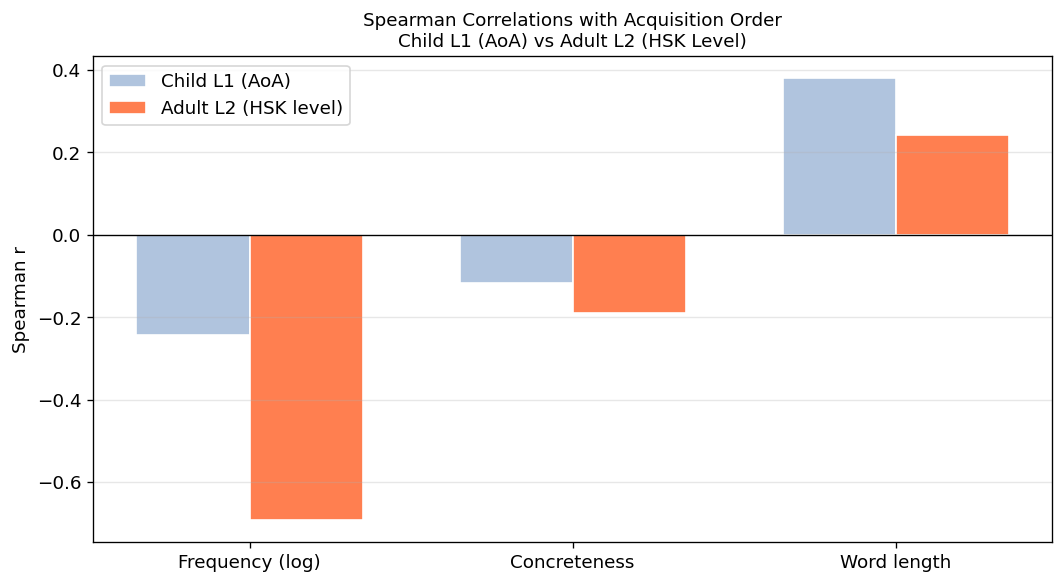

In [16]:
sr_df = pd.DataFrame(spearman_results).T

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(sr_df))
w = 0.35

ax.bar(x - w/2, sr_df['child_r'], w,
       label='Child L1 (AoA)', color='lightsteelblue', edgecolor='white')
ax.bar(x + w/2, sr_df['adult_r'], w,
       label='Adult L2 (HSK level)', color='coral', edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(sr_df.index)
ax.set_ylabel('Spearman r')
ax.set_title('Spearman Correlations with Acquisition Order\n'
             'Child L1 (AoA) vs Adult L2 (HSK Level)', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The Spearman correlations tell the core story of this project in a single table. All three features show statistically significant associations with acquisition order for both learners, but the magnitude and pattern differ substantially between them.

Frequency is a much stronger predictor for adult L2 learners (r = -0.693) than for children (r = -0.242). The negative sign means that more frequent words are acquired earlier - lower AoA and lower HSK level, which is the expected direction. But the difference in magnitude is impressive - frequency explains far more of the adult acquisition ordering than the child one. This is consistent with $H_1$.

Concreteness predicts both learners in the expected direction - more concrete words acquired earlier. But again, the magnitudes differ. For children (r = -0.117) the effect is weaker than for adults (r = -0.190). This is the opposite of what $H_2$ predicted - concreteness matters somewhat more for adult learners than for children in this dataset, which is an unexpected and interesting finding worth examining further in the modeling section.

Word length is positively correlated with acquisition order for both learners - longer words are acquired later. The effect is stronger for children (r = 0.379) than for adults (r = 0.242). In Mandarin, word length in characters is a measure of morphological complexity rather than phonological length as it would be in English. Most Mandarin words are one or two characters, with three-character words being relatively rare. A two-character word is therefore meaningfully more complex than a single character, as it combines two morphemes into a compound, and this added complexity appears to matter more for children building their first vocabulary than for adult learners who already possess full linguistic and conceptual awareness.

## 3.5 Scatter Plots

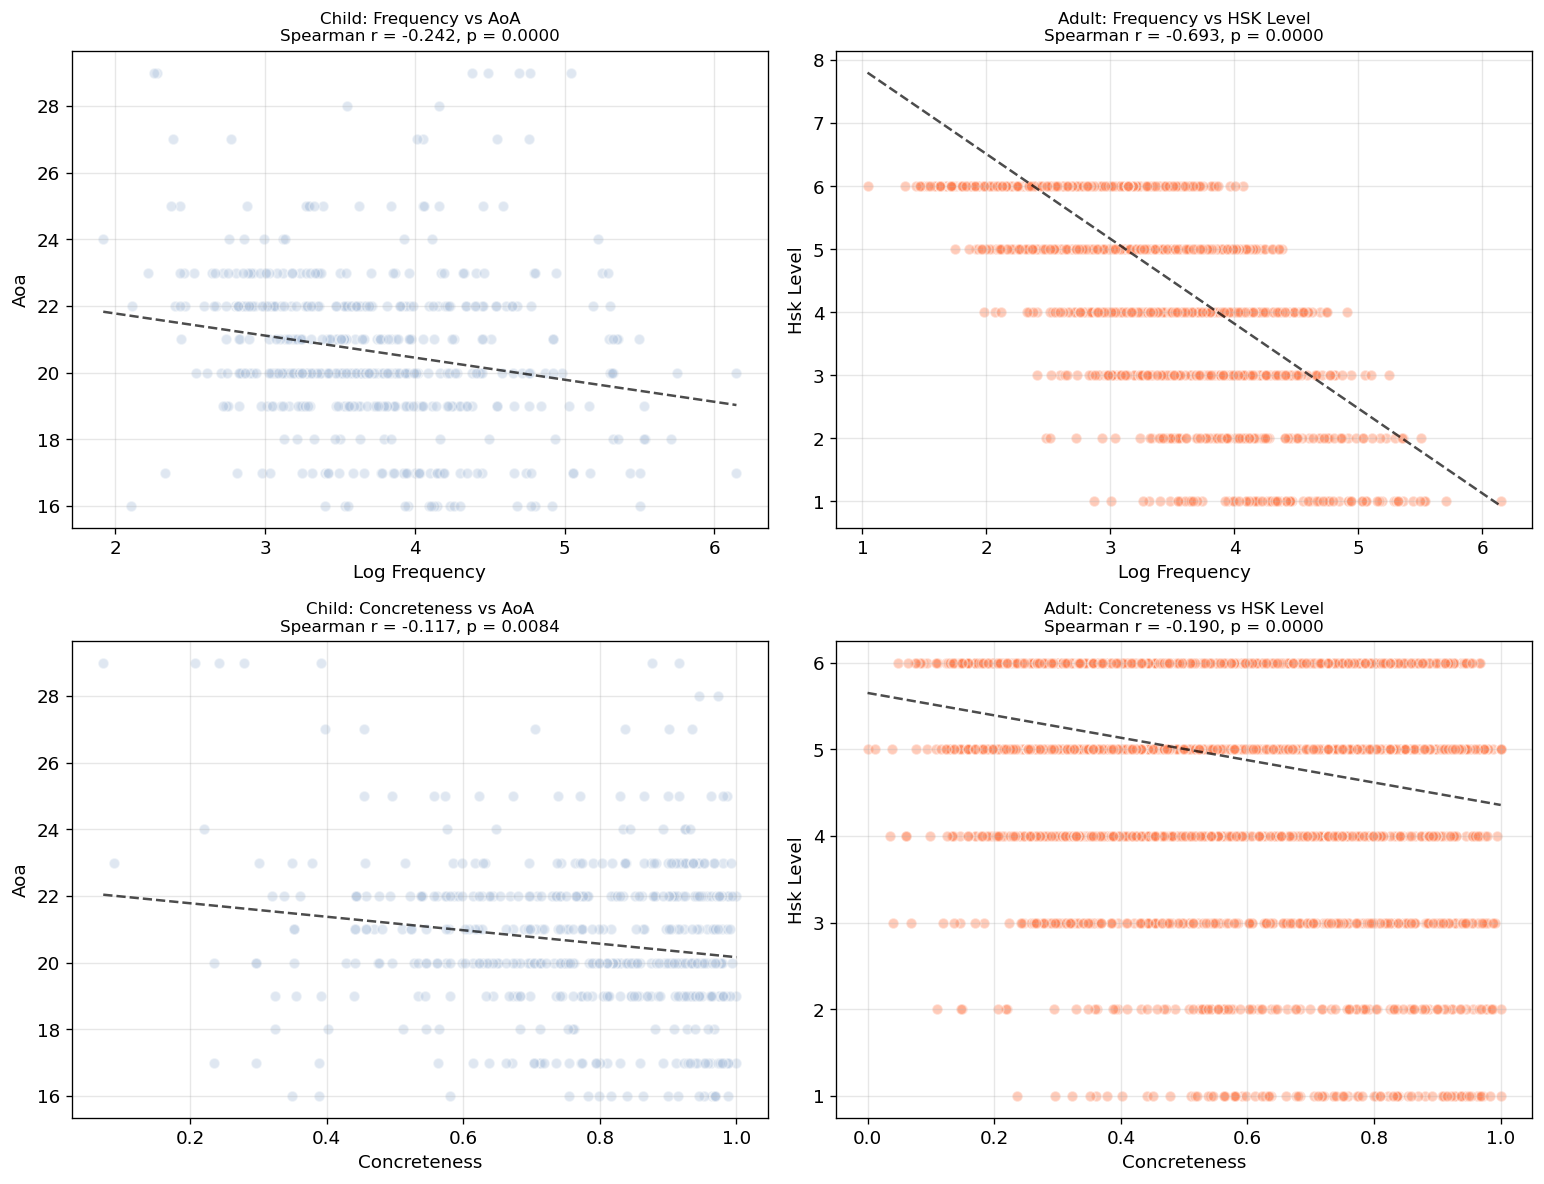

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

pairs = [
    (df_child_analysis, 'log_frequency', 'aoa',
     'Child: Frequency vs AoA', 'lightsteelblue'),
    (df_adult_analysis, 'log_frequency', 'hsk_level',
     'Adult: Frequency vs HSK Level', 'coral'),
    (df_child_analysis, 'concreteness', 'aoa',
     'Child: Concreteness vs AoA', 'lightsteelblue'),
    (df_adult_analysis, 'concreteness', 'hsk_level',
     'Adult: Concreteness vs HSK Level', 'coral'),
]

for ax, (df, xcol, ycol, title, color) in zip(axes.flatten(), pairs):
    ax.scatter(df[xcol], df[ycol],
               alpha=0.4, color=color, edgecolors='white', s=40)
    m, b = np.polyfit(df[xcol].values, df[ycol].values, 1)
    x_line = np.linspace(df[xcol].min(), df[xcol].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, alpha=0.7)
    r, p = spearmanr(df[xcol], df[ycol])
    ax.set_title(f'{title}\nSpearman r = {r:.3f}, p = {p:.4f}', fontsize=10)
    ax.set_xlabel(xcol.replace('_', ' ').title())
    ax.set_ylabel(ycol.replace('_', ' ').title())
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plots visualize the same relationships shown in the Spearman table and add useful nuance. The frequency plots offer the clearest visualization - the adult plot shows a steep, well-defined downward trend (high-frequency words cluster strongly at lower HSK levels), while the child plot shows a much flatter slope with considerable scatter, confirming that frequency is a far weaker signal for children than for adults. The horizontal banding in the adult frequency and concreteness plots is not a data artifact but a structural feature of HSK - with only six discrete levels, points naturally stack into horizontal lines. The concreteness plots both show modest downward trends consistent with the Spearman correlations, though the scatter is wide in both cases, reflecting that concreteness alone explains only a limited portion of acquisition order for either learner. Taken together, the four plots visually confirm the central pattern emerging from the analysis - adult L2 acquisition is substantially more frequency-driven than child acquisition, while both learners show a similar but weaker concreteness effect.

# 4. Machine Learning Models

## 4.1 Feature Set and Setup
The same three features are used for both models, making the comparison structurally clean:
$$
\mathbf{x}_i =
\left[
\log(\mathrm{frequency}_i),\ 
\mathrm{concreteness}_i,\ 
\mathrm{word\_length}_i
\right]
$$

Before modeling, a correlation check is performed to verify that the three features are not highly collinear. Collinearity would complicate individual coefficients, since if two features move tightly together, it becomes difficult to to attribute predictive power to either one independently.

In [18]:
print("Feature correlations - child dataset:")
print(df_child_analysis[FEATURES].corr().round(3))
print("\nFeature correlations — adult dataset:")
print(df_adult_analysis[FEATURES].corr().round(3))

Feature correlations - child dataset:
               log_frequency  concreteness  word_length
log_frequency          1.000        -0.449       -0.157
concreteness          -0.449         1.000        0.154
word_length           -0.157         0.154        1.000

Feature correlations — adult dataset:
               log_frequency  concreteness  word_length
log_frequency          1.000         0.039       -0.198
concreteness           0.039         1.000       -0.334
word_length           -0.198        -0.334        1.000


In [19]:
X_child = df_child_analysis[FEATURES].values
y_child = df_child_analysis['aoa'].values

X_adult = df_adult_analysis[FEATURES].values
y_adult = df_adult_analysis['hsk_level'].values

# Standardize features — essential for Ridge and Lasso
# so that regularization penalizes all features on the same scale
scaler_child = StandardScaler()
scaler_adult = StandardScaler()
X_child_scaled = scaler_child.fit_transform(X_child)
X_adult_scaled = scaler_adult.fit_transform(X_adult)

# Train/test splits (75/25)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_child_scaled, y_child, test_size=0.25, random_state=42)
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_adult_scaled, y_adult, test_size=0.25, random_state=42)

print(f"Child  — train: {X_c_train.shape[0]}, test: {X_c_test.shape[0]}")
print(f"Adult  — train: {X_a_train.shape[0]}, test: {X_a_test.shape[0]}")

Child  — train: 378, test: 126
Adult  — train: 2451, test: 818


The child training set contains 378 examples and the adult training set - 2451 examples. Both models use 5-fold cross-validation throughout. Absolute performance metrics are not directly comparable between the two models given the difference in dataset size. 

The child dataset shows the strongest inter-feature correlation between frewuency and concreteness (r = -0.449). The adult dataset exhibits weaker relationships among predictors, with all pairs below 0.35. No pair in either dataset exceeds the conventional collinearity threshold of 0.7, indicating that multicollinearity is unlikely to substantially affect model estimation. Therefore, all three features are retained for modeling.

## 4.2 Ridge Regression - Predicting Child AoA 
The target variable is AoA in months - a continuous variable. Ridge regression adds an L2 penalty to ordinary least squares cost functions:

$$
J(\mathbf{a})
=
\frac{1}{n}
\sum_{i=1}^{n}
(\tilde{y}_i - y_i)^2
+
\lambda
\sum_{j=1}^{m}
a_j^2
$$ 

The penalty term $\lambda \sum_{j=1}^{m} a_j^2$ shrinks all coefficients towards zero proportionally, reducing the variance at the cost of a small increase in bias. This is appropriate here because the three features show moderate correlations and the child dataset is relatively small.

In [20]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_child = GridSearchCV(
    Ridge(), param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2')
grid_child.fit(X_c_train, y_c_train)

best_alpha_child = grid_child.best_params_['alpha']
print(f"Best α (child): {best_alpha_child}")

ridge_child = Ridge(alpha=best_alpha_child)
ridge_child.fit(X_c_train, y_c_train)
y_c_pred = ridge_child.predict(X_c_test)

cv_scores_child = cross_val_score(
    Ridge(alpha=best_alpha_child),
    X_child_scaled, y_child,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2')

print(f"\nChild AoA — Ridge Regression:")
print(f"R²:              {r2_score(y_c_test, y_c_pred):.3f}")
print(f"MAE:             {mean_absolute_error(y_c_test, y_c_pred):.3f} months")
print(f"RMSE:            {np.sqrt(mean_squared_error(y_c_test, y_c_pred)):.3f} months")
print(f"CV R² (5-fold): {cv_scores_child.mean():.3f} ± {cv_scores_child.std():.3f}")

Best α (child): 10

Child AoA — Ridge Regression:
R²:              -0.155
MAE:             1.781 months
RMSE:            2.489 months
CV R² (5-fold): 0.199 ± 0.151


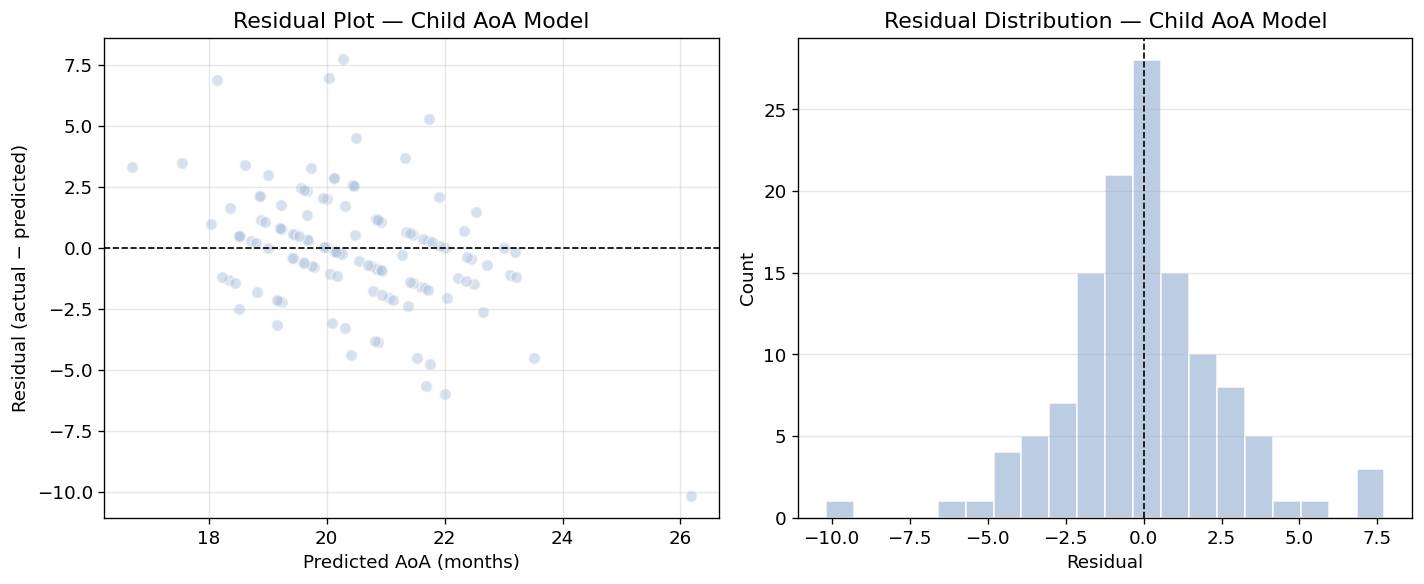

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

residuals_child = y_c_test - y_c_pred
axes[0].scatter(y_c_pred, residuals_child,
                alpha=0.5, color='lightsteelblue',
                edgecolors='white', s=50)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted AoA (months)')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residual Plot — Child AoA Model')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_child, bins=20,
             color='lightsteelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution — Child AoA Model')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The best regularization parameter found by grid search is $\alpha = 10$, indicating that meaningful shrinkage is needed, consistent with the moderate feature correlations noted in Section 4.1. The cross validation of $R^2$ of 0.199 is the more reliable performance estimate given the small dataset size; the negative test $R^2$ reflects the risk of a 126-word test split being unrepresentative rather than a fundamental model failure. The residuals show no obvious systematic structure and are approximately symmetric around zero, and the MAE of 1.781 months means predictions are off by less than two months on average, which is reasonable given that the full AoA range spans only 14 months.

## 4.3 Ridge Regression - Predicting HSK Level
HSK level is ordinal(1-6) and is treated as a continuous regression target here. This allows direct comparison of $R^2$ and feature coefficients with the child model. classification is added in Section 4.4. for a complementary view.

In [22]:
grid_adult = GridSearchCV(
    Ridge(), param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2')
grid_adult.fit(X_a_train, y_a_train)

best_alpha_adult = grid_adult.best_params_['alpha']
print(f"Best α (adult): {best_alpha_adult}")

ridge_adult = Ridge(alpha=best_alpha_adult)
ridge_adult.fit(X_a_train, y_a_train)
y_a_pred = ridge_adult.predict(X_a_test)

cv_scores_adult = cross_val_score(
    Ridge(alpha=best_alpha_adult),
    X_adult_scaled, y_adult,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2')

print(f"\nHSK Level — Ridge Regression:")
print(f"R²:             {r2_score(y_a_test, y_a_pred):.3f}")
print(f"MAE:            {mean_absolute_error(y_a_test, y_a_pred):.3f} levels")
print(f"RMSE:           {np.sqrt(mean_squared_error(y_a_test, y_a_pred)):.3f} levels")
print(f"CV R² (5-fold): {cv_scores_adult.mean():.3f} ± {cv_scores_adult.std():.3f}")

Best α (adult): 1

HSK Level — Ridge Regression:
R²:             0.543
MAE:            0.675 levels
RMSE:           0.898 levels
CV R² (5-fold): 0.525 ± 0.016


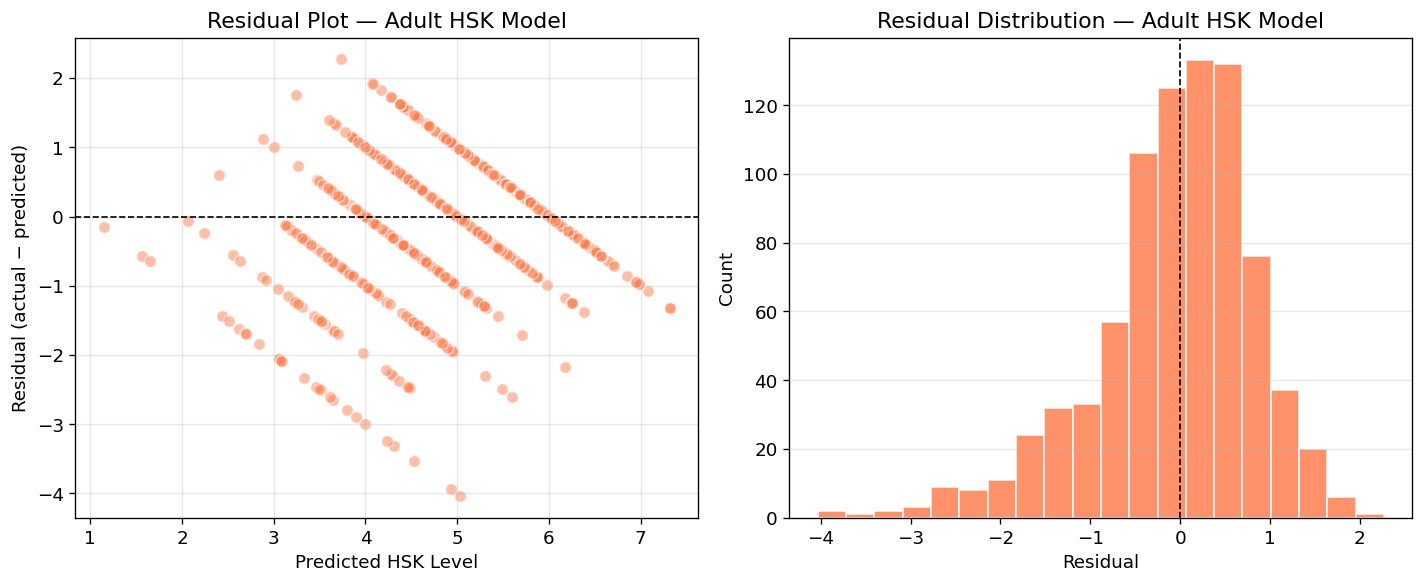

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

residuals_adult = y_a_test - y_a_pred
axes[0].scatter(y_a_pred, residuals_adult,
                alpha=0.5, color='coral',
                edgecolors='white', s=50)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted HSK Level')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residual Plot — Adult HSK Model')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_adult, bins=20,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution — Adult HSK Model')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The best regularization parameter is $\alpha = 1$ which is a much lighter regularization than the child model, consistent with the lower feature correlations in the adult dataset. The model performs substantially better than the child model: $R^2$ = 0.543 on the test set and 0.525 on cross validation, with the two being nearly identical - a good sign that the model generalizes well rather than overfitting. The MAE of 0.675 HSK levels means predictions are off by less than one level on average, which is meaningful given the 1-6 scale.

The residual plot reveals the structural feature noted earlier - the horizontal banding caused by HSK level being a discrete ordinal variable with only six values. A continuous regression model predicts smooth values while the actual targets are integers, creating systematic gaps in the residual pattern. This is not a model failure but an inherent limitation of treating an ordinal variable as continuous. The residual distribution is approximately symmetric and centered near zero, confirming the absence of systematic bias.

## 4.4 Random Forest Classification
Random Forest classification provides two things the regression models do not - a discrete prediction of acquisition class and feature importances - a model-native measure of how much each feature contributed to prediction decsions across all trees. This is used in Section 5 as a second, complementary view of feature importance alonglside the Ridge coefficients. 

For the child model, AoA is binned into three equal-frequency classes (early, middle, late) using quantile-based binning. For the adult model, HSK levels are used directly as six classes.

In [32]:
aoa_bins = pd.qcut(df_child_analysis['aoa'], q=3,
                    labels=['early', 'middle', 'late'])
y_child_class = aoa_bins.values

X_c_tr_c, X_c_te_c, y_c_tr_c, y_c_te_c = train_test_split(
    X_child_scaled, y_child_class,
    test_size=0.25, random_state=42,
    stratify=y_child_class)

rf_child = RandomForestClassifier(n_estimators=200, random_state=42)
rf_child.fit(X_c_tr_c, y_c_tr_c)

print("Child AoA — Random Forest (early / middle / late):")
print(classification_report(y_c_te_c,
                             rf_child.predict(X_c_te_c)))

cv_rf_child = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_child_scaled, y_child_class,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy')
print(f"CV Accuracy (5-fold): {cv_rf_child.mean():.3f} "
      f"± {cv_rf_child.std():.3f}")

Child AoA — Random Forest (early / middle / late):
              precision    recall  f1-score   support

       early       0.59      0.59      0.59        66
        late       0.29      0.24      0.26        21
      middle       0.33      0.36      0.34        39

    accuracy                           0.46       126
   macro avg       0.40      0.40      0.40       126
weighted avg       0.46      0.46      0.46       126

CV Accuracy (5-fold): 0.510 ± 0.038


In [33]:
X_a_tr_c, X_a_te_c, y_a_tr_c, y_a_te_c = train_test_split(
    X_adult_scaled, y_adult.astype(int),
    test_size=0.25, random_state=42,
    stratify=y_adult.astype(int))

rf_adult = RandomForestClassifier(n_estimators=200, random_state=42)
rf_adult.fit(X_a_tr_c, y_a_tr_c)

print("HSK Level — Random Forest (6 classes):")
print(classification_report(y_a_te_c,
                             rf_adult.predict(X_a_te_c),
                             target_names=[f'HSK {i}'
                                           for i in range(1, 7)]))

cv_rf_adult = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_adult_scaled, y_adult.astype(int),
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy')
print(f"CV Accuracy (5-fold): {cv_rf_adult.mean():.3f} "
      f"± {cv_rf_adult.std():.3f}")

HSK Level — Random Forest (6 classes):
              precision    recall  f1-score   support

       HSK 1       0.47      0.43      0.45        21
       HSK 2       0.18      0.15      0.16        27
       HSK 3       0.24      0.22      0.23        58
       HSK 4       0.29      0.25      0.27       112
       HSK 5       0.39      0.37      0.38       228
       HSK 6       0.71      0.79      0.75       372

    accuracy                           0.53       818
   macro avg       0.38      0.37      0.37       818
weighted avg       0.51      0.53      0.52       818

CV Accuracy (5-fold): 0.542 ± 0.019


The Random Forest results are consistent with the regression models. The adult classifier achieves 53% test accuracy and 54.2% on cross-validation which is well above the random chance on a 6-class problem (~17%). Per-class performance is uneven, with HSK 6 scoring the highest (recall 0.79), as it dominates the dataset. Lower HSK levels perform worse due to small support. The child classifier achieves 46% test accuracy and 51% on cross validation (as opposed to a random baseline of ~33%), a real but modest signal, consistent with the small dataset. 

## 4.5 Lasso - Feature Selection
Lasso (L1 regularization) sets some coefficients to exactly zero, performing automatic feature selection. Unlike Ridge, which shrinks all coefficients proportionally, Lasso forces a choice: it identifies which features contribute meaningfully and which do not.

$$
J(\mathbf{a})
=
\frac{1}{n}
\sum_{i=1}^{n}
(\tilde{y}_i-y_i)^2
+
\lambda
\sum_{j=1}^{m}
|a_j|
$$

Running Lasso on both models answers a specific question: if the model is forced to be sparse, does frequency survive as a predictor for children the same way it does for adults? Given the EDA results (frequency r = -0.242 for children versus -0.693 for adults) it is plausible that Lasso drops or heavily shrinks frequency for the child model while retaining it strongly for the adult model.

In [26]:
param_grid_lasso = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]}

lasso_child = GridSearchCV(
    Lasso(max_iter=10000), param_grid_lasso,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2')
lasso_child.fit(X_c_train, y_c_train)

lasso_adult = GridSearchCV(
    Lasso(max_iter=10000), param_grid_lasso,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2')
lasso_adult.fit(X_a_train, y_a_train)

print(f"Lasso — Child model "
      f"(α={lasso_child.best_params_['alpha']}):")
for feat, coef in zip(FEATURES,
                       lasso_child.best_estimator_.coef_):
    status = 'RETAINED' if coef != 0 else 'ZEROED OUT'
    print(f"  {feat:<22}: {coef:>8.4f}  [{status}]")

print(f"\nLasso — Adult model "
      f"(α={lasso_adult.best_params_['alpha']}):")
for feat, coef in zip(FEATURES,
                       lasso_adult.best_estimator_.coef_):
    status = 'RETAINED' if coef != 0 else 'ZEROED OUT'
    print(f"  {feat:<22}: {coef:>8.4f}  [{status}]")

Lasso — Child model (α=0.01):
  log_frequency         :  -1.0197  [RETAINED]
  concreteness          :  -1.0177  [RETAINED]
  word_length           :   0.9799  [RETAINED]

Lasso — Adult model (α=0.001):
  log_frequency         :  -0.8326  [RETAINED]
  concreteness          :  -0.1888  [RETAINED]
  word_length           :   0.1017  [RETAINED]


Lasso retained all three features in both models. No feature was zeroed out, but the coefficient magnitudes are revealing. In the child model ($\alpha$ = 0.01, all three features contribute with roughly equal weight - frequency (-1.020), concreteness (-1.018) and word length (0.980) are almost identical in magnitude. No single feature dominates. In the adult model ($\alpha$ = 0.001), frequency dominates strongly (-0.833) while concreteness is much weaker (-0.189) and word length minimal (0.102). The prediction that Lasso might zero out frequency for children did not materialize, but what emerged instead is arguably more interesting - for children, acquisition order is shaped by a balance of all three features; for adults, frequency is the primary driver by a wide margin. This contrast directly supports $H_1$ and will be examined further in the feature importance comparison in Section 5.

## 4.6 PCA - the Word Feature Space
PCA reduces the three-dimensional feature space to two dimensions for visualization. This allows us to see whether child vocabulary and HSK vocabulary occupy different regions of the same feature space, and whether the two datasets are structurally comparable or fundamentally different in their feature distributions.

Variance explained: PC1 = 0.496, PC2 = 0.307, Total = 0.803

PCA loadings (feature contributions to each component):


,PC1,PC2
log_frequency,-0.473,0.795
concreteness,-0.567,-0.604
word_length,0.674,0.050


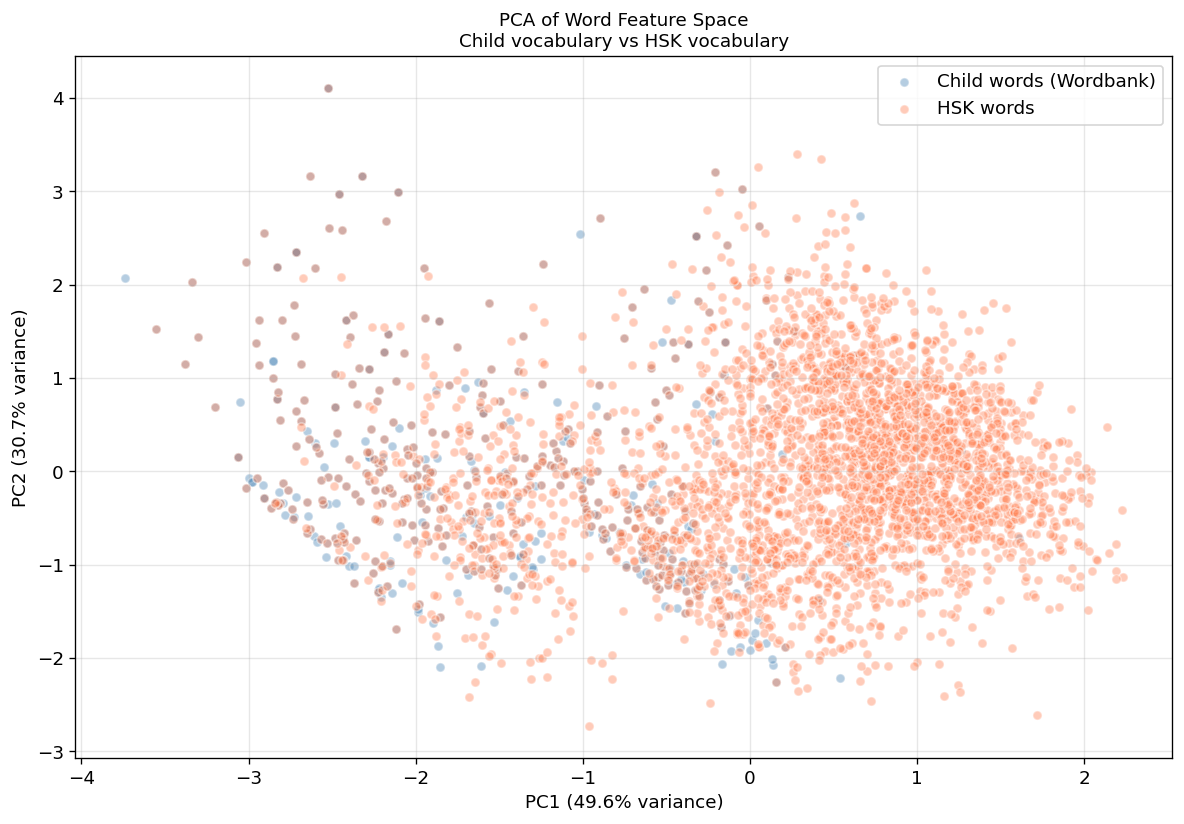

In [27]:
all_words = pd.concat([
    df_child_analysis[FEATURES].assign(source='child'),
    df_adult_analysis[FEATURES].assign(source='adult')
], ignore_index=True)

X_all = StandardScaler().fit_transform(all_words[FEATURES])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

all_words['PC1'] = X_pca[:, 0]
all_words['PC2'] = X_pca[:, 1]

print(f"Variance explained: "
      f"PC1 = {pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.3f}, "
      f"Total = {pca.explained_variance_ratio_.sum():.3f}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2'])
print("\nPCA loadings (feature contributions to each component):")
display(loadings.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
for source, color, label in [
    ('child', 'steelblue', 'Child words (Wordbank)'),
    ('adult', 'coral',          'HSK words')
]:
    mask = all_words['source'] == source
    ax.scatter(all_words.loc[mask, 'PC1'],
               all_words.loc[mask, 'PC2'],
               alpha=0.4, s=30, color=color,
               edgecolors='white', label=label)

ax.set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(
    'PCA of Word Feature Space\n'
    'Child vocabulary vs HSK vocabulary', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The two components explain 80.3% of total variance. PC1 (49.6%) separates longer, more abstract words from shorter, more concrete ones. PC2 (30.7%) separates high-frequency from low-frequency and more concrete words. Child words are distributed across the left and center of the plot but are notably absent from the far right. HSK words cover the full feature space but are most densely concentrated on the right side - the region of lower concreteness, lower frequency and greater word length that corresponds to advanced vocabulary. The two datasets overlap substantially in the center and left, but the rightward concentration of HSK words reflects the breadth of adult L2 vocabulary relative to the more concrete, shorter-word profile of early child vocabulary.

# 5. The Three Learners - Feature Importance Comparison
This section brings together the results from the ML models into the central comparison of the project. Three complementary views are presented: Ridge regression coefficients, Random Foredt feature importances, and a spectrum visualization that places all three learners on a single axis.

## 5.1 Ridge Coefficient Comparison
Ridge regression coefficients, after standardization of all features, are directly comparable within each model - a larger absolute coefficient means that feature contributed more to the prediction. Comparing the same coefficients across the two models reveals how the relative importance of each feature shifts between the child and adult leraner.

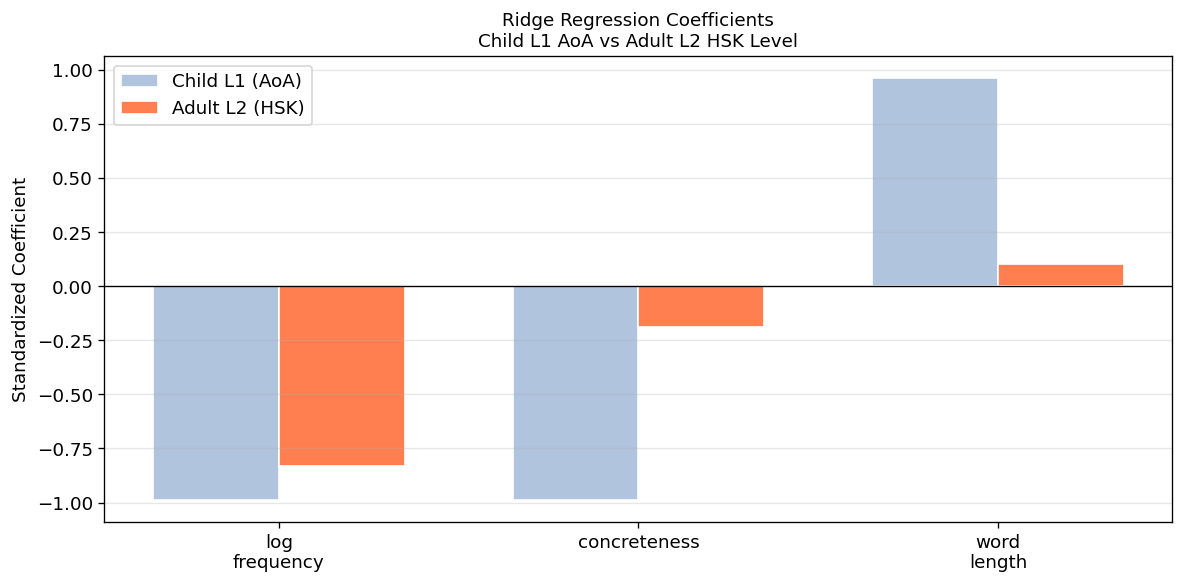

,Child (AoA),Adult L2 (HSK)
Feature,,
log_frequency,-0.9900,-0.8332
concreteness,-0.9859,-0.1895
word_length,0.9643,0.1023


In [28]:
coef_df = pd.DataFrame({
    'Feature':        FEATURES,
    'Child (AoA)':    ridge_child.coef_,
    'Adult L2 (HSK)': ridge_adult.coef_
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(FEATURES))
w = 0.35

ax.bar(x - w/2, coef_df['Child (AoA)'], w,
       label='Child L1 (AoA)',
       color='lightsteelblue', edgecolor='white')
ax.bar(x + w/2, coef_df['Adult L2 (HSK)'], w,
       label='Adult L2 (HSK)',
       color='coral', edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f.replace('_', '\n') for f in FEATURES])
ax.set_ylabel('Standardized Coefficient')
ax.set_title('Ridge Regression Coefficients\n'
             'Child L1 AoA vs Adult L2 HSK Level',
             fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(coef_df.set_index('Feature').round(4))

The cofficient table makes the contrast between the two learners immediately visible. 

For children, all three features carry comparable weights - frequency (-0.990), concreteness (-0.959) and word lenght (0.964) have nearly identical magnitudes in absolute value. This might seem surprising given that my earlier project in this series found concreteness t be the dominant predictor of child word acquisition in English, far outweighing frequency. The difference has two explanations. First, the earlier project compared concreteness against a near-zero frequency signal - in Mandarin child vocabulary, frequency is a stronger predictor than it was in english, giving it more weight in the model. Second, wordd length was not included as a feature in the earlier analysis, and in Mandarin it turns out to be a meaningful predictor in its own right (r = 0.379) when three genuinely predictive features compete in a regularized model, the weights distribute more evenly. Concreteness still matters for children, its coefficient is nearly as large as frequency's, but it no longer dominates by default.

For adults, the picture is completely different: frequency dominates strongly (-0.833) while concreteness shrinks to -0.190 and word length becomes minimal at 0.102.

The sign directions are consistent across both models and with the hypotheses: more frequent words are acquired earlier (negative frequency coefficients), more concrete words are acquired earlier(negative concreteness coefficients), and longer words are acquired later (positive word length coefficients). What differs between the two learnes is not the direction of these effects but their relative magnitude - and that difference is the core finding of this project.

## 5.2 Random Forest Feature Importances
Random Forest feature importances provide a second, model native perspective on which features drove the predictions. Unlike Ridge coefficients, which assume a linear relationship, Random Forest importances capture non-linear contributions and are not affected by feature correlations in the same way.

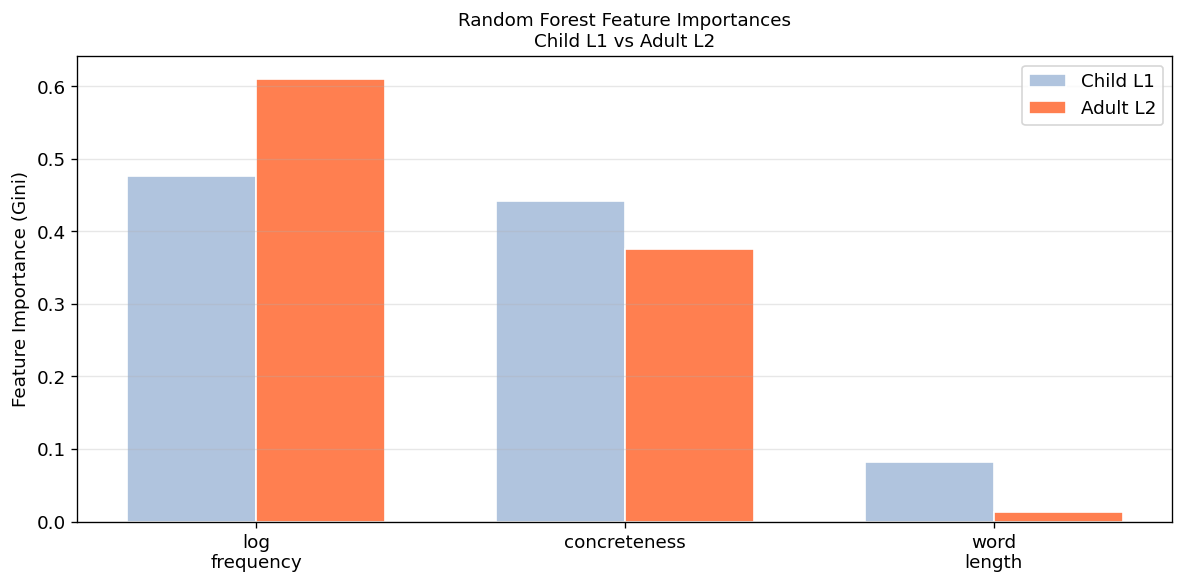

,Child (RF),Adult L2 (RF)
Feature,,
log_frequency,0.4761,0.6105
concreteness,0.4414,0.3762
word_length,0.0826,0.0133


In [29]:
imp_df = pd.DataFrame({
    'Feature':       FEATURES,
    'Child (RF)':    rf_child.feature_importances_,
    'Adult L2 (RF)': rf_adult.feature_importances_
})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(FEATURES))

ax.bar(x - w/2, imp_df['Child (RF)'], w,
       label='Child L1',
       color='lightsteelblue', edgecolor='white')
ax.bar(x + w/2, imp_df['Adult L2 (RF)'], w,
       label='Adult L2',
       color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f.replace('_', '\n') for f in FEATURES])
ax.set_ylabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importances\n'
             'Child L1 vs Adult L2', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(imp_df.set_index('Feature').round(4))

The Random Forest importances confirm frequency dominance for adults (0.611) versus children (0.476), consistent with the Ridge coefficients and Spearman correlations. However, they also reveal something the ridge model obscured: for children, concreteness (0.441) is nearly as important as frequency (0.476), as the gap between them is only 0.035, while word length (0.083) contributes substantially less. For adults, concreteness (0.376) remains meaningful but drops relative to frequency, and word length becomes negligible (0.013).

This is where the Random Forest and Ridge results diverge slightly and the divergence is informative. Ridge assigned nearly equal absolute coefficients to all three features of the child model, suggesting a balanced three-way contribution. The Random Forest tells a more nuanced storry - frequency and concreteness share most of the predictive weights for children while word length contributes little, whereas for adults frequency dominates and the other two features recede. This contrasts with my earlier project, which found concreteness to be a stronger predictor than frequency for English-speaking children. Here the Random Forest places frequency marginally above concreteness for the child model, though the two are close enough that no strong claim of dominance can be made in either direction.

## 5.3 The Spectrum - Where Does the Adult L2 Learner Sit?
The central question of this project is not just whether the two learner models differ, but where the adult L2 learner sits relative to both endpoints of the learning spectrum: the fully embodied child at one end and the purely statistical language model at the other.

A spectrum score is constructed for each learner based on the relative importance of frequency versus concreteness in predicting acquisition order. The Spearman correlations from Section 3.4 are used as the basis, taking absolute values to compare the strength of each signal regardless of sign direction:

$$
\mathrm{spectrum\ score}
=
\frac{
|r_{\mathrm{frequency}}|
+
|r_{\mathrm{concreteness}}|
}{
|r_{\mathrm{frequency}}|
}
$$

A score near 1 means frequency dominates relative to concreteness - the learner sits close to the model end. A score near 0 meas concreteness dominates. the language model is assigned a score 1.0 by definition, since in this project word frequency in the Chinese BabyLM corpus serves aas the sole proxy for the model's learning signal.

In [30]:
def spectrum_score(r_freq, r_conc):
    """
    Compute a spectrum score from 0 (concreteness-driven)
    to 1 (frequency-driven), using absolute Spearman correlations.
    Absolute values are used because both correlations are negative
    (higher frequency and higher concreteness both predict earlier
    acquisition), so the sign reflects direction, not dominance.
    The language model scores 1.0 by definition.
    """
    denom = abs(r_freq) + abs(r_conc)
    if denom == 0:
        return 0.0
    return abs(r_freq) / denom

r_freq_child = spearman_results['Frequency (log)']['child_r']
r_conc_child = spearman_results['Concreteness']['child_r']
r_freq_adult = spearman_results['Frequency (log)']['adult_r']
r_conc_adult = spearman_results['Concreteness']['adult_r']

score_child  = spectrum_score(r_freq_child, r_conc_child)
score_adult  = spectrum_score(r_freq_adult, r_conc_adult)
score_model  = 1.0

print("Spectrum scores:")
print(f"  Mandarin children (L1):  {score_child:.3f}")
print(f"  Adult L2 learners (HSK): {score_adult:.3f}")
print(f"  Language model:          {score_model:.3f}")

Spectrum scores:
  Mandarin children (L1):  0.674
  Adult L2 learners (HSK): 0.785
  Language model:          1.000


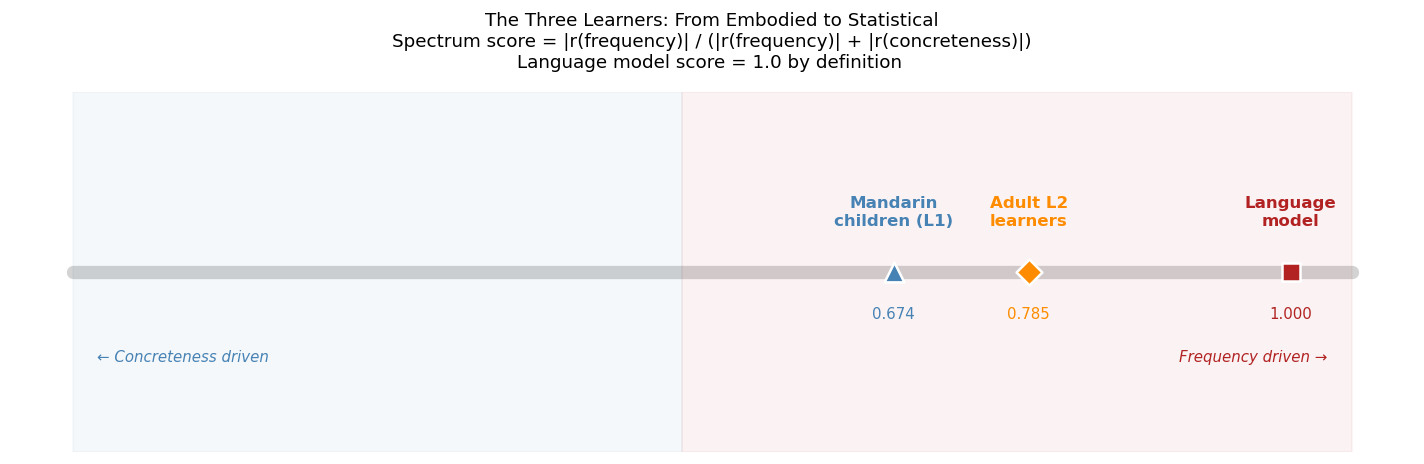

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot([0, 1.05], [0, 0], color='lightgrey',
        linewidth=8, solid_capstyle='round', zorder=1)
ax.axvspan(0,    0.5,  alpha=0.05, color='steelblue')
ax.axvspan(0.5,  1.05, alpha=0.05, color='firebrick')

learners = [
    (score_child,  'Mandarin\nchildren (L1)',  'steelblue',  '^', 140),
    (score_adult,  'Adult L2\nlearners',        'darkorange', 'D', 120),
    (score_model,  'Language\nmodel',           'firebrick',  's', 120),
]

for score, label, color, marker, size in learners:
    ax.scatter(score, 0, color=color, marker=marker,
               s=size, zorder=5,
               edgecolors='white', linewidth=1.5)
    ax.annotate(label, (score, 0),
                xytext=(0, 28), textcoords='offset points',
                ha='center', fontsize=10,
                color=color, fontweight='bold')
    ax.annotate(f'{score:.3f}', (score, 0),
                xytext=(0, -28), textcoords='offset points',
                ha='center', fontsize=9, color=color)

ax.text(0.02, -0.15, '← Concreteness driven',
        ha='left', fontsize=9,
        color='steelblue', style='italic')
ax.text(1.03, -0.15, 'Frequency driven →',
        ha='right', fontsize=9,
        color='firebrick', style='italic')

ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.3, 0.3)
ax.axis('off')
ax.set_title(
    'The Three Learners: From Embodied to Statistical\n'
    'Spectrum score = |r(frequency)| / '
    '(|r(frequency)| + |r(concreteness)|)\n'
    'Language model score = 1.0 by definition ',
    fontsize=11, pad=15)

plt.tight_layout()
plt.show()

The spectrum places all three learners in the frequency-driven half of the axis - above 0.5, which reflects that in both Mandarin datasets used here, frequency is a stronger signal than concreteness accross all three learners. The gradient across the three is nonetheless meaningful: children (0.674) are the least frequency driven, adult L2 learners (0.785) are substantially more so, and the language model sits at 1.0 by definition. The gap between children and adults (0.111) is larger than it might appear given the scale - it represents a meaningful shift in the relative weight of frequency versus concreteness when moving from L1 child acquisition to adult L2 learning. This is consistent with $H_1$ and $H_3$: adult L2 acquisition sits closer to the model end of the spectrum than child acquisition does. 

## 5.4 Summary - The Three Hypotheses Revisited
The evidence across Spearman correlations, Ridge regression, Lasso and Random Forest converges on the following:

**$H_1$ - Frequency is a stronger predictor of adult L2 acquisition order than of child L1 acquisition order:** Strongly supported. The adult Spearman r for frequency (-0.693) is nearly three times larger in magnitude than the child's (-0.242). The Lasso coefficients tell a complementary story - in the child model, frequency shares its weight almost equally with concreteness and wod length, while the adult model frequency dominates by a wide margin. The Random Forest importances confirm this - frequency accounts for 61% of the adult model's predictive weight versus 48% in the child model. Across all four analytical approaches, the same pattern holds.

**$H_2$ - Concreteness is a weaker predictor of adult L2 acquisition order than of child L1 acquisition order:** Not supported as stated, and this is the most surprising finding of the project. The Spearman correlation for concreteness is actually stronger for adults (r = -0.190) than for children (r = -0.117). In the Random Forest importances, concreteness accounts for 44% of predictive weight in the child model and 38% in the adult model, consistent with the direction of $H_2$ but a way smaller difference than expected and overshadowed by the Spearman finding that the raw correlation is actually stronger for adults.

Two explanations are worth considering. First, the child dataset after concreteness coverage filtering is gheavily skewed toward the concrete end of the vocabulary, with a mean normalized at 0.77, which compresses the variance that concreteness can explain. Second, concrete words are generally considered easier entry points into a new language - they map onto perceivable, pointable things in a way that abstract words do not. This advantage may be strongest at low profficiency levels, and since the HSK dataset spans across all proficiency levels, the early-level concreteness effect may still be visible in aggregate. Either way, $H_2$ is not supported and this is stated honestly.

**$H_3$ - The overall feature importance profile of the adult L2 model resembles the model's frequency-based learning signal more closely than the child model does:** Supported. The spectrum score places the adult learner at 0.785 versus the child at 0.674 on a scale where 1.0 represents the language model's frequency signal. Notably both learners sit in the frequency-dominant half of the spectrum, reflecting that in both datasets, frequency outweighs concreteness as a predictor. The adult learner is nevertheless meaningfully closer to the model end, driven by the substantially larger role of frequency relative to concreteness in adult L2 acquisition compared to child L1 acquisition.



# 6. Discussion and Limitations
## 6.1 What the Models Found
This project set out to ask whether adult L2 acquisition sits closer to the language model ens of a spectrum defined by frequency-driven versus concreteness-driven learning. The answer, across four analytical approaches is: yes, but with a nuance.

The clearest finding is that frequency is a substantially stronger predictor of adult L2 acquisitionorder than of child L1 acquisition order. The Spearman correlation for frequency is nearly three times larger in magnitude for adults (r = -0.693) than for children (r = -0.242). The Lasso and Ridge coefficients tell the same story - in the adult model, frequency dominates; in the child model, all three features compete with comparable weight. The Random Forest importances confirm it independently using a non-linear model. This finding is robust across every method applied and directly supports $H_1$.

The concreteness finding is more complicated. $H_2$ predicted that concreteness would matter less for adult L2 than for children. The Spearman correlation is actually slightly stronger for adults (r = -0.190) than for children (r = -0.117), which runs counter to intuition and prediction. The Random Forest importances partially recover the expected direction (concreteness accounts for 44% of predictive weight in the child model versus 38% in the adult model), but the difference is small and the raw correlation finding complicates any single claim. $H_2$ is not supported as stated.

Two explanations for the concreteness finding are worth holding. First, the child dataset after concreteness coverage filtering is skewed toward the highly concrete end of the vocabulary (mean 0.77 on a 0-1 scale) which leaves little varieance for concreteness to explain. The concreteness effect for children may be understated by the data rather than genuinely weaker. Second, there is plausible proficiency-level explanation - concrete words are generally considered easier entry points into a new language, and their advantage may be strongest at lower proficiency levels where learners rely more on perceptable, tangible meaning. Since the HSK dataset covers all six proficiency levels, a genuine concreteness advantage in the early levels may remain visible in aggregate even for adult learners. Neither explanation can be confirmed from this data alone, but both are plausible and both point toward the same conclusion: the $H_2$ is interesting precisely because it does not resolve cleanly.

The spectrum visualization places all three learners in the frequency-dominant half of a 0-1 scale - children at 0.674, adult L2 learners at 0.785, language model at 1.0 (by default). This means that in both Mandarin datasets, frequency outweighs concreteness as a predictor even for children, which differs from the English finding in my earlier project where frequency was near zero. Mandarin child vocabulary may be more frequency-structured than English child vocabulary, or the concreteness coverage limitations may have introduced bias. What remains clear is the gradient - the adult learner sits meaningfully closer to the model end than the child does, and this supports $H_3$.

One cross-linguistic observation is worth noting even though this project does not have the data to test it formally. The earlier project in this series found frequency to be a near-zero predictor for English-speaking children (r $\approx$ -0.007), while here it reaches r = -0.242 for mandarin children . Whether this reflects something genuine about Mandarin child acquisition, a difference in the corpora used, or the concreteness coverage bias in the mandarin child dataset, is an open question - and an interesting one for future work.

## 6.2 Limitations
**HSK as a proxy.** Themost fundamental limitation is that HSK level reflects curriculum design decisions rather than empirical measurement of what adult learners actually acquire first. The grading is based on expert judgement about what learners need to know at each proficiency stage, not on observational data on acquisition order. This makes the adult acquisition proxy considerably noisier than the Wordbank AoA measure, and any conclusions about adult L2 acquisition order should be interpreted with this in mind throughout.

**Concreteness coverage.** The child analysis is limited to 504 words - less than two-thirds of the Wordbank Beijing Mandarin checklist - because no single freely avaiable concreteness norm dataset covers the full range of early child vocabulary in simplified Mandarin. The gap is not random: the words missing concreteness ratings are disproportionately sound words, grammatical particles and functional words, meaning the child dataset is biased toward concrete content words. This almost certainly compresses the concreteness effect for children and maes cross-learner comparisons of concreteness less reliable than comparisons of frequency.

**Frequency as a model proxy.** Word frequency in the Chinese BabyLM corpus is a principled but coarse approximation of what a language model knows. Modern language models learn from much more complex patterns and richer representations than just frequency counts. The spectrum score and feature importance comparisons are therefore comparisons between human learners and a simplified representation of a model, not between human learners and an actual trained model. A more coomplete analysis would use surprisal or embedding distances from a model actually trained on the Chinese BabyLM corpus.

**Dataset size assymetry.** The child dataset (504 words) and the adult dataset (3269 words) differ substantially in size, which means that the child models have less data to learn from and their performance metrics are less stable. The negative test $R^2$ for the child Ridge model is a direct consequence of this. The focus on feature importance profiles and Spearman correlations rather than absolute model performance mitigates this but does not eliminate it. 

**No causal claims.** All findings are correlational. The project identifies patterns in the data and asks whether they are consistent with the hypotheses. It does not establish that frequency causes adult L2 acquisition to proceed in a particular order, or that embodiment causes children the learn certain words first. The mechanisms behind the patterns remain a question for other methods and larger datasets.

## 6.3 The BabyLM Connection
The BabyLM challenge asks what happens when you train a language model on developmentally plausible data - roughly the amount of text a child encounters in its first years of life. Its Chinese counterpart, which provided the frequency corpus used in this project, applies the same logic to Mandarin. The premise underlying both is that child acquisition is the right reference point for thinking about what it means for a model to learn language efficiently and human-like.

This project raises a quiet question about this premise. The findings here suggest that adult L2 learners, when acquiring a new language primarily through text and explicit study, show a learning profile that is structurally closer to what a frequency-based model learns than to what children learn. If that is right, then adult L2 acquisition patterns might be a natural complement to child acquisition as a benchmark and an alternative reference point that captures a different kind of human language learning, one that happens to share more structural features with model trainingg.

In practice, using adult L2 acquisition as a model benchmark would require an adult L2 corpus - graded readers, structured learning materials, the texts that adult learners actually encounter when learning a new language. The copyright constraints on commercially published learning materials make this non-trivial, but the comparison does not yet exist in the published literature and the question is worth asking. This project cannot answer it. What it can do is point toward it as a natural step.


# 7. Conclusion
This project started with a personal observation: learning Mandarin as an adult felt different from how my children learn their languages - more deliberate, more text-driven and less anchored in direct interaction with the world. The question it follows is whether that perceived difference shows up in the data.

It turns out that it does.
Frequency turned out to be a substantialy stronger predictor of adult L2 acquisition order than of child L1 acquisition order. Accross correlation analysis and multiple machine learning models, adult L2 acquisition consistently appeared more frequency driven, placing it closer to the statistical learning profile represented by the language-model end of the proposed spectrum.

What this project can conclude is that the three learners are not interchangeable. They share a language and a common set of lexical features, but the relative importance of those features differ systematically across learners. Adult L2 acquisition, as measured here through HSK level, behaves more like a frequency-driven learning process than child L1 acquisition does. Whether that makes it a better or worse model benchmark is a question for future work - and one worth asking.

# 8. References

## Datasets: ##
Frank, M.C., Braginsky, M., Yurovsky, D., & Marchman, V.A. (2017). Wordbank: An open repository for developmental vocabulary data. Journal of Child Language, 44(3), 677–694. Available at: https://wordbank.stanford.edu, Accessed on 2026-06-07


Hu, M. et al. Chinese BabyLM Challenge corpus (Available at: https://huggingface.co/datasets/chinese-babylm-org/babylm-zho-100M, Accessed on 2026-06-07, Processed and saved as a csv file available here: https://drive.google.com/file/d/1sb2_Fq67EGy6WySI-44L16wUytFeVlJY/view?usp=drive_link)


HSK Vocabulary Lists (old HSK system, 6 levels). Available at: https://github.com/plaktos/hsk_csv, Accessed on 2026-06-07


Xu, X. & Li, J. (2020). Concreteness ratings for 9,877 two-character Chinese words. PLOS ONE, 15(5), e0232133. Available at: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0232133
, Accessed on 2026-06-07

Liu, Y., Shu, H., & Li, P. (2007). Word naming and psycholinguistic norms: Chinese. Behavior Research Methods, 39, 192–198. Database available at the Chinese Single-character Word Database (CSWD) at https://blclab.org/introduction-to-the-database/, accessed on 2026-06-11

**All datasets available here:**
https://drive.google.com/drive/folders/13qEDS3YRXskJjXPesqNmPn9uImHmopVl?usp=drive_link 

## Background reading: ##
Peneva-Kargiou, S. (2026). Comparing Word Learning in Children and Language Models: A Data Science Case Study. SoftUni Data Science Course Project. Available at: https://github.com/Slavena1/Softuni-Data-Science-Final-Project/tree/main 